In [3]:
!pip install -q kaggle

In [2]:
import os

os.environ["KAGGLE_USERNAME"] =
os.environ["KAGGLE_KEY"] =

# Test access to the SemanticKITTI dataset
!kaggle datasets files hbenallal/semantickitti

SyntaxError: invalid syntax (4270634423.py, line 3)

In [1]:
import os

os.makedirs("/content/semantic_kitti_sample", exist_ok=True)

for i in range(10):
    filename = f"dataset/sequences/00/velodyne/{i:06d}.bin"

    !kaggle datasets download \
        -d hbenallal/semantickitti \
        -f "$filename" \
        -p /content/semantic_kitti_sample \
        --unzip

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.90M/1.90M [00:00<00:00, 151MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.90M/1.90M [00:00<00:00, 105MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.90M/1.90M [00:00<00:00, 30.9MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.89M/1.89M [00:00<00:00, 85.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.89M/1.89M [00:00<00:00, 66.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.89M/1.89M [00:00<00:00, 37.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unknown
100% 1.88M/1.88M [00:00<00:00, 45.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/hbenallal/semantickitti
License(s): unkn

In [2]:
import glob
import os
import numpy as np

files = sorted(
    glob.glob("/content/semantic_kitti_sample/*.bin")
)

print("Frames found:", len(files))

for path in files:
    points = np.fromfile(path, dtype=np.float32).reshape(-1, 4)

    xyz = points[:, :3]
    intensity = points[:, 3]

    horizontal_range = np.sqrt(xyz[:, 0]**2 + xyz[:, 1]**2)

    print(
        f"{os.path.basename(path)} | "
        f"points={len(points):6d} | "
        f"range={horizontal_range.min():5.2f}-{horizontal_range.max():5.2f} m | "
        f"Z={xyz[:,2].min():6.2f}-{xyz[:,2].max():5.2f} m | "
        f"intensity={intensity.min():.2f}-{intensity.max():.2f} | "
        f"NaN={np.isnan(points).sum()} | "
        f"Inf={np.isinf(points).sum()}"
    )

Frames found: 10
000000.bin | points=124668 | range= 1.25-79.74 m | Z=-11.56- 2.83 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000001.bin | points=124605 | range= 1.20-79.76 m | Z=-11.30- 2.82 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000002.bin | points=124478 | range= 1.26-79.81 m | Z=-11.03- 2.84 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000003.bin | points=124167 | range= 1.19-79.75 m | Z=-10.76- 2.85 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000004.bin | points=123969 | range= 1.22-80.00 m | Z=-10.49- 2.87 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000005.bin | points=123924 | range= 1.26-79.68 m | Z=-10.20- 2.88 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000006.bin | points=123373 | range= 1.21-79.59 m | Z= -2.83- 2.89 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000007.bin | points=122765 | range= 1.20-80.34 m | Z= -6.36- 2.88 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000008.bin | points=122123 | range= 1.27-80.19 m | Z= -2.68- 2.89 m | intensity=0.00-0.99 | NaN=0 | Inf=0
000009.bin | points=121357 | 

In [3]:
import numpy as np
from collections import defaultdict, Counter
import time
import os

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
BANDS = [
    (0,  10,  0.05, 0),
    (10, 30,  0.15, 1),
    (30, 100, 0.50, 2),
]

FILES = [
    f"/content/semantic_kitti_sample/{i:06d}.bin"
    for i in range(10)
]

# ─────────────────────────────────────────
# CORE FUNCTIONS
# ─────────────────────────────────────────

def load_points(path):
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)

def assign_levels(points):
    dist     = np.sqrt(points[:,0]**2 + points[:,1]**2)
    levels   = np.zeros(len(points), dtype=np.int32)
    vox_size = np.zeros(len(points), dtype=np.float32)
    for d_min, d_max, size, level in BANDS:
        mask = (dist >= d_min) & (dist < d_max)
        levels[mask]   = level
        vox_size[mask] = size
    return levels, vox_size, dist

def build_hash_grid(points, levels, vox_size):
    coords = np.floor(
        points[:,:3] / vox_size[:,None]
    ).astype(np.int32)

    hash_grid = defaultdict(lambda: {
        "point_indices": [],
        "level": None,
        "vox_size": None
    })

    for i in range(len(points)):
        key = (
            int(levels[i]),
            int(coords[i,0]),
            int(coords[i,1]),
            int(coords[i,2])
        )
        hash_grid[key]["point_indices"].append(i)
        hash_grid[key]["level"]    = int(levels[i])
        hash_grid[key]["vox_size"] = float(vox_size[i])

    return hash_grid

def compute_voxel_features(hash_grid, points):
    features = {}
    for key, data in hash_grid.items():
        idx = data["point_indices"]
        pts = points[idx]
        z   = pts[:,2]
        features[key] = {
            "point_count":    len(idx),
            "height_mean":    float(z.mean()),
            "height_min":     float(z.min()),
            "height_max":     float(z.max()),
            "height_var":     float(z.var()),
            "height_range":   float(z.max() - z.min()),
            "intensity_mean": float(pts[:,3].mean()),
            "level":          data["level"],
            "vox_size":       data["vox_size"],
        }
    return features

def compute_voxel_centers(hash_grid):
    centers = {}
    for key, data in hash_grid.items():
        _, ix, iy, iz = key
        vs = data["vox_size"]
        centers[key] = (
            (ix + 0.5) * vs,
            (iy + 0.5) * vs,
            (iz + 0.5) * vs,
        )
    return centers

def uniform_voxel_count(points, size=0.05):
    coords = np.floor(points[:,:3] / size).astype(np.int32)
    return len(set(map(tuple, coords.tolist())))

def correctness_checks(hash_grid, features):
    errors = []

    # Check 1 — no duplicate keys
    all_keys = list(hash_grid.keys())
    if len(all_keys) != len(set(all_keys)):
        errors.append("KEY COLLISION detected")

    # Check 2 — no empty voxels
    empty = [k for k,v in hash_grid.items()
             if len(v["point_indices"]) == 0]
    if empty:
        errors.append(f"{len(empty)} empty voxels found")

    # Check 3 — voxel size matches level
    size_map = {0: 0.05, 1: 0.15, 2: 0.50}
    mismatches = [
        k for k, v in features.items()
        if abs(v["vox_size"] - size_map[k[0]]) > 1e-6
    ]
    if mismatches:
        errors.append(f"{len(mismatches)} voxel size mismatches")

    # Check 4 — point count > 0
    zero_pts = [k for k,v in features.items()
                if v["point_count"] == 0]
    if zero_pts:
        errors.append(f"{len(zero_pts)} voxels with zero points")

    return errors

# ─────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────

print(f"{'Frame':<12} {'Points':>8} {'Uniform':>10} "
      f"{'Adaptive':>10} {'Reduction':>10} "
      f"{'L0':>8} {'L1':>8} {'L2':>8} "
      f"{'Time(ms)':>10} {'Checks'}")
print("-" * 100)

all_results = []

for fpath in FILES:
    fname = os.path.basename(fpath)
    t0    = time.time()

    # Pipeline
    points              = load_points(fpath)
    levels, vox_size, dist = assign_levels(points)
    hash_grid           = build_hash_grid(points, levels, vox_size)
    features            = compute_voxel_features(hash_grid, points)
    centers             = compute_voxel_centers(hash_grid)

    elapsed_ms = (time.time() - t0) * 1000

    # Counts
    uniform_v  = uniform_voxel_count(points)
    adaptive_v = len(hash_grid)
    reduction  = uniform_v / adaptive_v

    level_counts = Counter(k[0] for k in hash_grid.keys())

    # Correctness
    errors      = correctness_checks(hash_grid, features)
    check_str   = "✓ PASS" if not errors else f"✗ {errors[0]}"

    result = {
        "frame":      fname,
        "points":     len(points),
        "uniform":    uniform_v,
        "adaptive":   adaptive_v,
        "reduction":  reduction,
        "l0":         level_counts[0],
        "l1":         level_counts[1],
        "l2":         level_counts[2],
        "time_ms":    elapsed_ms,
        "errors":     errors,
    }
    all_results.append(result)

    print(f"{fname:<12} {len(points):>8,} {uniform_v:>10,} "
          f"{adaptive_v:>10,} {reduction:>9.2f}x "
          f"{level_counts[0]:>8,} {level_counts[1]:>8,} "
          f"{level_counts[2]:>8,} {elapsed_ms:>9.1f}ms  {check_str}")

# ─────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────

print("\n" + "=" * 100)
print("SUMMARY ACROSS 10 FRAMES")
print("=" * 100)

avg_points   = np.mean([r["points"]   for r in all_results])
avg_uniform  = np.mean([r["uniform"]  for r in all_results])
avg_adaptive = np.mean([r["adaptive"] for r in all_results])
avg_red      = np.mean([r["reduction"]for r in all_results])
avg_time     = np.mean([r["time_ms"]  for r in all_results])
avg_l0       = np.mean([r["l0"]       for r in all_results])
avg_l1       = np.mean([r["l1"]       for r in all_results])
avg_l2       = np.mean([r["l2"]       for r in all_results])

print(f"  Avg points per frame : {avg_points:,.0f}")
print(f"  Avg uniform voxels   : {avg_uniform:,.0f}")
print(f"  Avg adaptive voxels  : {avg_adaptive:,.0f}")
print(f"  Avg reduction        : {avg_red:.2f}x")
print(f"  Avg time per frame   : {avg_time:.1f} ms")
print(f"  Avg L0 voxels (5cm)  : {avg_l0:,.0f}")
print(f"  Avg L1 voxels (15cm) : {avg_l1:,.0f}")
print(f"  Avg L2 voxels (50cm) : {avg_l2:,.0f}")

all_errors = [e for r in all_results for e in r["errors"]]
if not all_errors:
    print("\n  ✓ All correctness checks passed across all 10 frames")
else:
    print(f"\n  ✗ Errors found: {set(all_errors)}")

print("\nLEVEL BREAKDOWN (averages)")
print(f"  L0 (5cm,  0-10m)  : {avg_l0:,.0f} voxels  "
      f"({avg_l0/avg_adaptive*100:.1f}% of adaptive)")
print(f"  L1 (15cm, 10-30m) : {avg_l1:,.0f} voxels  "
      f"({avg_l1/avg_adaptive*100:.1f}% of adaptive)")
print(f"  L2 (50cm, 30-100m): {avg_l2:,.0f} voxels  "
      f"({avg_l2/avg_adaptive*100:.1f}% of adaptive)")

Frame          Points    Uniform   Adaptive  Reduction       L0       L1       L2   Time(ms) Checks
----------------------------------------------------------------------------------------------------
000000.bin    124,668     91,767     62,158      1.48x   33,922   23,934    4,302    4444.0ms  ✓ PASS
000001.bin    124,605     91,495     62,256      1.47x   34,389   23,592    4,275    5801.2ms  ✓ PASS
000002.bin    124,478     91,177     62,134      1.47x   34,635   23,373    4,126    5100.2ms  ✓ PASS
000003.bin    124,167     90,572     61,926      1.46x   35,151   22,772    4,003    4961.9ms  ✓ PASS
000004.bin    123,969     90,316     61,899      1.46x   35,461   22,426    4,012    6979.4ms  ✓ PASS
000005.bin    123,924     89,992     61,519      1.46x   35,126   22,359    4,034    4257.6ms  ✓ PASS
000006.bin    123,373     89,469     60,909      1.47x   34,838   22,167    3,904    5701.6ms  ✓ PASS
000007.bin    122,765     89,219     60,534      1.47x   34,671   21,969    3,894    


Processing 000000.bin
Saved voxels → /content/voxel_store/000000_voxels.npz
VOXEL QUALITY REPORT

── Overall ──
  Total voxels      : 62,158
  Total points      : 124,668
  Compression ratio : 2.01 pts/voxel

── Points per voxel ──
  Min    : 1
  Max    : 18
  Mean   : 2.01
  Median : 2.0
  1-pt voxels  : 28,371 (45.6%)
  >10pt voxels : 94 (0.2%)

── Height range per voxel ──
  Min  : 0.0000 m
  Max  : 0.4880 m
  Mean : 0.0100 m
  Suspicious (>2m) : 0
  Flat (=0m)       : 28,382

── Correctness checks ──
  ✓ height_min > height_max        : 0 ✓
  ✓ height_range ≠ hmax-hmin (>1e-4): 0 ✓

── Per-level breakdown ──

  L0 (5cm) — 33,922 voxels
    pts/voxel    : min=1 mean=1.84 max=8
    height_range : min=0.000 mean=0.002 max=0.049
    single-pt    : 15,575 (45.9%)

  L1 (15cm) — 23,934 voxels
    pts/voxel    : min=1 mean=2.21 max=18
    height_range : min=0.000 mean=0.014 max=0.148
    single-pt    : 10,752 (44.9%)

  L2 (50cm) — 4,302 voxels
    pts/voxel    : min=1 mean=2.18 max=15
 

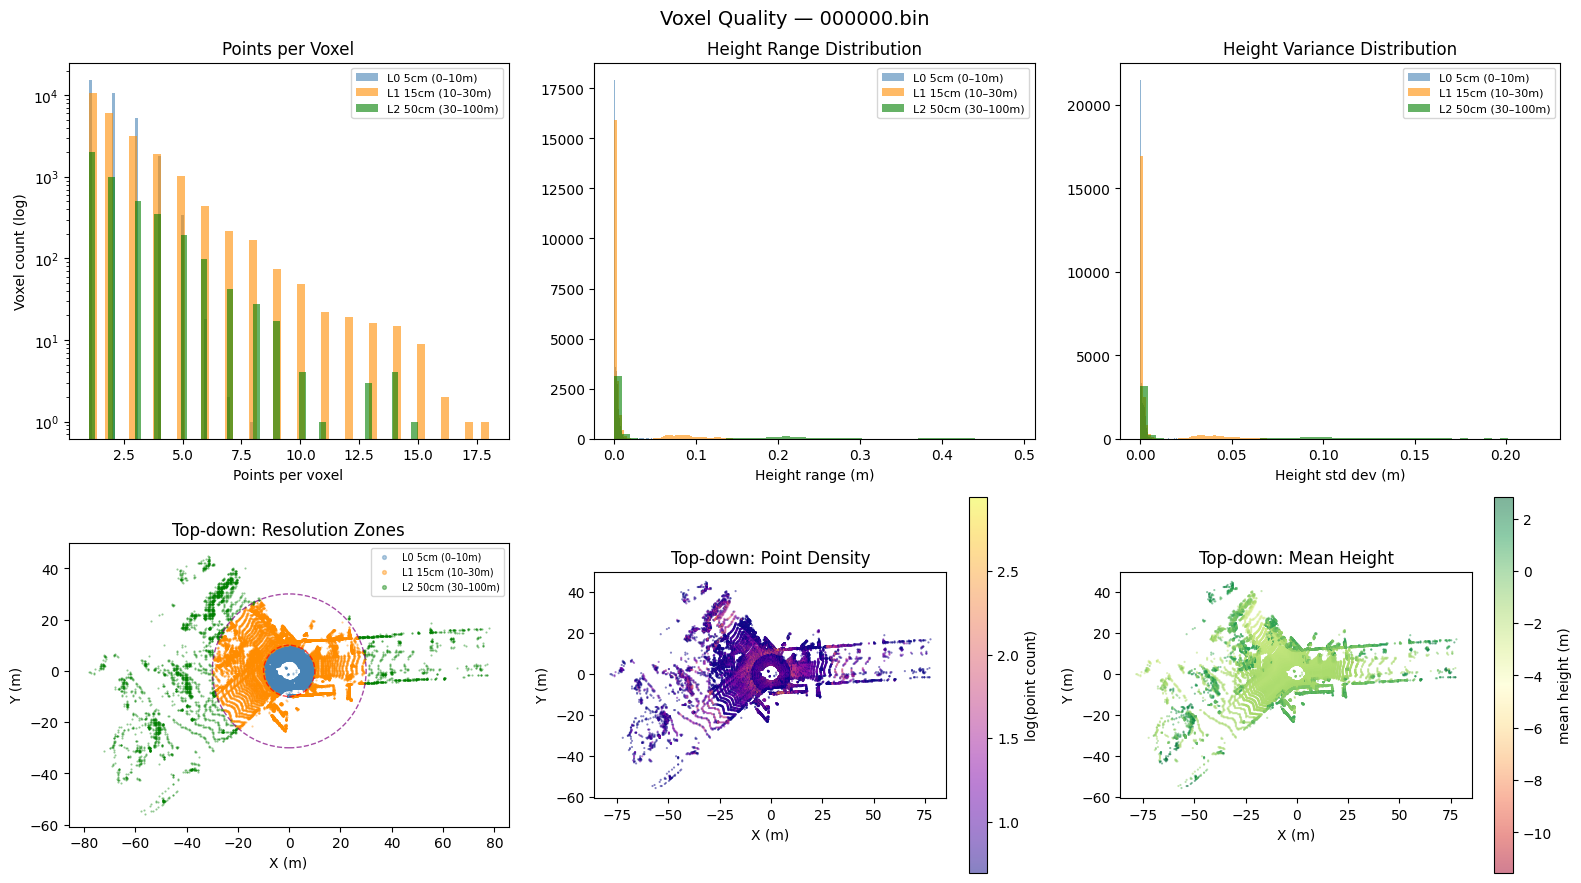

Saved: /content/voxel_store/000000_quality.png

── Storage verification: 000000 ──
  ✓ voxel count
  ✓ height_mean match
  ✓ height_min match
  ✓ point_count match
  ✓ levels match
  File size : 1326.4 KB

Processing 000001.bin
Saved voxels → /content/voxel_store/000001_voxels.npz
VOXEL QUALITY REPORT

── Overall ──
  Total voxels      : 62,256
  Total points      : 124,605
  Compression ratio : 2.00 pts/voxel

── Points per voxel ──
  Min    : 1
  Max    : 18
  Mean   : 2.00
  Median : 2.0
  1-pt voxels  : 28,352 (45.5%)
  >10pt voxels : 71 (0.1%)

── Height range per voxel ──
  Min  : 0.0000 m
  Max  : 0.4870 m
  Mean : 0.0099 m
  Suspicious (>2m) : 0
  Flat (=0m)       : 28,367

── Correctness checks ──
  ✓ height_min > height_max        : 0 ✓
  ✓ height_range ≠ hmax-hmin (>1e-4): 0 ✓

── Per-level breakdown ──

  L0 (5cm) — 34,389 voxels
    pts/voxel    : min=1 mean=1.84 max=8
    height_range : min=0.000 mean=0.002 max=0.049
    single-pt    : 15,770 (45.9%)

  L1 (15cm) — 23,592

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import time

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
SIZE_MAP = np.array([0.05, 0.15, 0.50], dtype=np.float32)

FILES = [
    f"/content/semantic_kitti_sample/{i:06d}.bin"
    for i in range(10)
]

SAVE_DIR = "/content/voxel_store"
os.makedirs(SAVE_DIR, exist_ok=True)


# ─────────────────────────────────────────
# LOAD
# ─────────────────────────────────────────
def load_points(path):
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)


# ─────────────────────────────────────────
# PIPELINE
# ─────────────────────────────────────────
class VoxelPipeline:
    """
    Optimized adaptive voxelization pipeline.

    Key changes vs original:
      1. Level assignment: fully vectorized, no Python loops.
      2. Key hashing: unchanged (already fast).
      3. Feature aggregation: replaced 6x np.add.at / np.minimum.at /
         np.maximum.at with a single argsort + np.*.reduceat per feature.
         This eliminates unbuffered scatter ops over ~100k points.
      4. No pre-allocated buffers (they required zero-fill slicing which
         added overhead; NumPy allocation of ~100k floats is negligible).
    """

    def process(self, points):
        N = len(points)
        x = points[:, 0]
        y = points[:, 1]
        z = points[:, 2]
        inten = points[:, 3]

        # ── 1. assign levels (fully vectorized) ──────────────
        dist = np.sqrt(x * x + y * y)

        levels   = np.where(dist < 10, np.int32(0),
                   np.where(dist < 30, np.int32(1),
                                       np.int32(2)))
        vox_size = SIZE_MAP[levels]          # (N,) float32

        # ── 2. voxel coordinates ─────────────────────────────
        coords = np.floor(
            points[:, :3] / vox_size[:, None]
        ).astype(np.int32)                   # (N, 3)

        # ── 3. unique voxel keys ─────────────────────────────
        # Pack [level, ix, iy, iz] into a void dtype for np.unique
        keys_c = np.ascontiguousarray(
            np.stack([levels, coords[:, 0],
                      coords[:, 1], coords[:, 2]], axis=1)
        )                                    # (N, 4) int32
        keys_v = keys_c.view(
            np.dtype((np.void, keys_c.dtype.itemsize * 4))
        ).ravel()

        unique_void, inverse = np.unique(keys_v, return_inverse=True)
        unique_keys = unique_void.view(np.int32).reshape(-1, 4)
        V = len(unique_keys)

        # ── 4. sort points by voxel index (one sort, reused) ─
        order          = np.argsort(inverse, kind='stable')
        inv_sorted     = inverse[order]

        # Group start positions (one per unique voxel)
        diff    = np.diff(inv_sorted)
        splits  = np.flatnonzero(diff) + 1
        starts  = np.r_[0, splits]          # length V

        # ── 5. per-voxel feature aggregation (reduceat) ──────
        z_sorted     = z[order].astype(np.float64)
        inten_sorted = inten[order].astype(np.float64)
        ones         = np.ones(N, dtype=np.float64)

        count  = np.add.reduceat(ones,         starts).astype(np.int32)
        z_sum  = np.add.reduceat(z_sorted,     starts)
        z_sum2 = np.add.reduceat(z_sorted**2,  starts)
        z_min  = np.minimum.reduceat(z_sorted, starts)
        z_max  = np.maximum.reduceat(z_sorted, starts)
        i_sum  = np.add.reduceat(inten_sorted, starts)

        # Derived statistics
        z_mean  = z_sum  / count
        z_var   = np.maximum(z_sum2 / count - z_mean**2, 0.0)  # clamp fp noise
        z_range = z_max  - z_min
        i_mean  = i_sum  / count

        # ── 6. voxel centres ─────────────────────────────────
        lv = unique_keys[:, 0]
        vs = SIZE_MAP[lv]
        cx = (unique_keys[:, 1] + 0.5) * vs
        cy = (unique_keys[:, 2] + 0.5) * vs
        cz = (unique_keys[:, 3] + 0.5) * vs

        return {
            "unique_keys":    unique_keys,
            "levels":         lv,
            "vox_size":       vs,
            "center_x":       cx,
            "center_y":       cy,
            "center_z":       cz,
            "point_count":    count,
            "height_mean":    z_mean,
            "height_min":     z_min,
            "height_max":     z_max,
            "height_var":     z_var,
            "height_range":   z_range,
            "intensity_mean": i_mean,
        }


# ─────────────────────────────────────────
# STORAGE
# ─────────────────────────────────────────
def save_voxels(features, frame_name, save_dir):
    frame_id   = os.path.splitext(frame_name)[0]
    out_path   = os.path.join(save_dir, f"{frame_id}_voxels.npz")
    center_xyz = np.stack([
        features["center_x"],
        features["center_y"],
        features["center_z"],
    ], axis=1).astype(np.float32)

    np.savez_compressed(
        out_path,
        keys         = features["unique_keys"].astype(np.int32),
        levels       = features["levels"].astype(np.int32),
        vox_size     = features["vox_size"].astype(np.float32),
        center_xyz   = center_xyz,
        point_count  = features["point_count"].astype(np.int32),
        height_mean  = features["height_mean"].astype(np.float32),
        height_min   = features["height_min"].astype(np.float32),
        height_max   = features["height_max"].astype(np.float32),
        height_var   = features["height_var"].astype(np.float32),
        height_range = features["height_range"].astype(np.float32),
        intensity    = features["intensity_mean"].astype(np.float32),
    )
    return out_path


def load_voxels(frame_id, save_dir):
    path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
    d    = np.load(path)
    return {
        "unique_keys":    d["keys"],
        "levels":         d["levels"],
        "vox_size":       d["vox_size"],
        "center_x":       d["center_xyz"][:, 0],
        "center_y":       d["center_xyz"][:, 1],
        "center_z":       d["center_xyz"][:, 2],
        "point_count":    d["point_count"],
        "height_mean":    d["height_mean"],
        "height_min":     d["height_min"],
        "height_max":     d["height_max"],
        "height_var":     d["height_var"],
        "height_range":   d["height_range"],
        "intensity_mean": d["intensity"],
    }


def save_metadata(results, save_dir):
    meta_path = os.path.join(save_dir, "metadata.json")
    with open(meta_path, "w") as f:
        json.dump(results, f, indent=2)
    return meta_path


# ─────────────────────────────────────────
# QUALITY REPORT
# ─────────────────────────────────────────
def voxel_quality_report(features, points):
    pcount = features["point_count"]
    hrange = features["height_range"]
    hvar   = features["height_var"]
    levels = features["levels"]

    print("=" * 60)
    print("VOXEL QUALITY REPORT")
    print("=" * 60)

    print(f"\n── Overall ──")
    print(f"  Total voxels      : {len(pcount):,}")
    print(f"  Total points      : {len(points):,}")
    print(f"  Compression ratio : {len(points)/len(pcount):.2f} pts/voxel")

    print(f"\n── Points per voxel ──")
    print(f"  Min    : {pcount.min()}")
    print(f"  Max    : {pcount.max()}")
    print(f"  Mean   : {pcount.mean():.2f}")
    print(f"  Median : {np.median(pcount):.1f}")
    print(f"  1-pt voxels  : {(pcount==1).sum():,} "
          f"({(pcount==1).mean()*100:.1f}%)")
    print(f"  >10pt voxels : {(pcount>10).sum():,} "
          f"({(pcount>10).mean()*100:.1f}%)")

    print(f"\n── Height range per voxel ──")
    print(f"  Min  : {hrange.min():.4f} m")
    print(f"  Max  : {hrange.max():.4f} m")
    print(f"  Mean : {hrange.mean():.4f} m")
    print(f"  Suspicious (>2m) : {(hrange>2).sum():,}")
    print(f"  Flat (=0m)       : {(hrange==0).sum():,}")

    # Stronger correctness check
    hmin = features["height_min"]
    hmax = features["height_max"]
    bad_order  = (hmin > hmax + 1e-4).sum()
    range_err  = np.abs(hrange - (hmax - hmin))
    bad_range  = (range_err > 1e-4).sum()
    print(f"\n── Correctness checks ──")
    print(f"  ✓ height_min > height_max        : {bad_order} "
          f"{'✓' if bad_order == 0 else '✗ WARNING'}")
    print(f"  ✓ height_range ≠ hmax-hmin (>1e-4): {bad_range} "
          f"{'✓' if bad_range == 0 else '✗ WARNING'}")

    print(f"\n── Per-level breakdown ──")
    size_labels = {0: "5cm", 1: "15cm", 2: "50cm"}
    for lv in [0, 1, 2]:
        mask = levels == lv
        if mask.sum() == 0:
            continue
        pc = pcount[mask]
        hr = hrange[mask]
        print(f"\n  L{lv} ({size_labels[lv]}) — {mask.sum():,} voxels")
        print(f"    pts/voxel    : "
              f"min={pc.min()} mean={pc.mean():.2f} max={pc.max()}")
        print(f"    height_range : "
              f"min={hr.min():.3f} mean={hr.mean():.3f} max={hr.max():.3f}")
        print(f"    single-pt    : {(pc==1).sum():,} "
              f"({(pc==1).mean()*100:.1f}%)")

    print(f"\n── Spatial coverage ──")
    print(f"  X : {features['center_x'].min():.1f} "
          f"to {features['center_x'].max():.1f} m")
    print(f"  Y : {features['center_y'].min():.1f} "
          f"to {features['center_y'].max():.1f} m")
    print(f"  Z : {features['center_z'].min():.1f} "
          f"to {features['center_z'].max():.1f} m")


def check_zone_boundaries(features):
    print(f"\n── Zone boundary check ──")
    cx   = features["center_x"]
    cy   = features["center_y"]
    lv   = features["levels"]
    dist = np.sqrt(cx**2 + cy**2)

    for boundary, lo, hi, lv_a, lv_b in [
        (10, 8,  12, 0, 1),
        (30, 28, 32, 1, 2),
    ]:
        zone = (dist > lo) & (dist < hi)
        if zone.sum() == 0:
            continue
        la = (lv[zone] == lv_a).sum()
        lb = (lv[zone] == lv_b).sum()
        print(f"\n  {lo}–{hi}m (around {boundary}m boundary)")
        print(f"    L{lv_a} voxels : {la}")
        print(f"    L{lv_b} voxels : {lb}")

    TOLERANCE = 0.25
    l0_far  = ((lv == 0) & (dist > 10 + TOLERANCE)).sum()
    l2_near = ((lv == 2) & (dist < 30 - TOLERANCE)).sum()
    print(f"\n  L0 voxels beyond {10+TOLERANCE}m : {l0_far} "
          f"{'✓' if l0_far==0 else '✗ WARNING'}")
    print(f"  L2 voxels within {30-TOLERANCE}m : {l2_near} "
          f"{'✓' if l2_near==0 else '✗ WARNING'}")
    print(f"  (tolerance = {TOLERANCE}m = half one L2 voxel width)")


# ─────────────────────────────────────────
# QUALITY PLOTS
# ─────────────────────────────────────────
def voxel_quality_plots(features, frame_name, save_dir):
    pcount = features["point_count"]
    hrange = features["height_range"]
    hvar   = features["height_var"]
    levels = features["levels"]
    cx     = features["center_x"]
    cy     = features["center_y"]

    colors = ['steelblue', 'darkorange', 'green']
    labels = ['L0 5cm (0–10m)', 'L1 15cm (10–30m)', 'L2 50cm (30–100m)']

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f"Voxel Quality — {frame_name}", fontsize=14)

    ax = axes[0, 0]
    for lv in [0, 1, 2]:
        mask = levels == lv
        ax.hist(pcount[mask], bins=50, alpha=0.6,
                color=colors[lv], label=labels[lv])
    ax.set_xlabel("Points per voxel")
    ax.set_ylabel("Voxel count (log)")
    ax.set_title("Points per Voxel")
    ax.legend(fontsize=8)
    ax.set_yscale('log')

    ax = axes[0, 1]
    for lv in [0, 1, 2]:
        mask = levels == lv
        ax.hist(hrange[mask], bins=50, alpha=0.6,
                color=colors[lv], label=labels[lv])
    ax.set_xlabel("Height range (m)")
    ax.set_title("Height Range Distribution")
    ax.legend(fontsize=8)

    ax = axes[0, 2]
    for lv in [0, 1, 2]:
        mask = levels == lv
        ax.hist(np.sqrt(hvar[mask] + 1e-9), bins=50, alpha=0.6,
                color=colors[lv], label=labels[lv])
    ax.set_xlabel("Height std dev (m)")
    ax.set_title("Height Variance Distribution")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    for lv in [0, 1, 2]:
        mask = levels == lv
        ax.scatter(cx[mask], cy[mask], s=0.3, alpha=0.4,
                   color=colors[lv], label=labels[lv])
    for r, c in [(10, 'red'), (30, 'purple')]:
        circle = plt.Circle((0, 0), r, color=c, fill=False,
                             linewidth=1, linestyle='--', alpha=0.7)
        ax.add_patch(circle)
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
    ax.set_title("Top-down: Resolution Zones")
    ax.legend(fontsize=7, markerscale=5)
    ax.set_aspect('equal')

    ax = axes[1, 1]
    sc = ax.scatter(cx, cy, c=np.log1p(pcount),
                    s=0.3, alpha=0.5, cmap='plasma')
    plt.colorbar(sc, ax=ax, label='log(point count)')
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
    ax.set_title("Top-down: Point Density")
    ax.set_aspect('equal')

    ax = axes[1, 2]
    sc = ax.scatter(cx, cy, c=features["height_mean"],
                    s=0.3, alpha=0.5, cmap='RdYlGn')
    plt.colorbar(sc, ax=ax, label='mean height (m)')
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
    ax.set_title("Top-down: Mean Height")
    ax.set_aspect('equal')

    plt.tight_layout()
    plot_path = os.path.join(
        save_dir,
        f"{os.path.splitext(frame_name)[0]}_quality.png"
    )
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {plot_path}")


# ─────────────────────────────────────────
# STORAGE VERIFICATION
# ─────────────────────────────────────────
def verify_storage(frame_id, save_dir, original_features):
    print(f"\n── Storage verification: {frame_id} ──")
    loaded = load_voxels(frame_id, save_dir)

    checks = [
        ("voxel count",
         len(loaded["unique_keys"]) == len(original_features["unique_keys"])),
        ("height_mean match",
         np.allclose(loaded["height_mean"],
                     original_features["height_mean"].astype(np.float32),
                     atol=1e-4)),
        ("height_min match",
         np.allclose(loaded["height_min"],
                     original_features["height_min"].astype(np.float32),
                     atol=1e-4)),
        ("point_count match",
         np.array_equal(loaded["point_count"],
                        original_features["point_count"])),
        ("levels match",
         np.array_equal(loaded["levels"],
                        original_features["levels"])),
    ]

    all_ok = True
    for name, result in checks:
        status = "✓" if result else "✗"
        print(f"  {status} {name}")
        if not result:
            all_ok = False

    npz_path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
    size_kb  = os.path.getsize(npz_path) / 1024
    print(f"  File size : {size_kb:.1f} KB")
    return all_ok


# ─────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────
pipeline = VoxelPipeline()
_ = pipeline.process(load_points(FILES[0]))   # warmup

all_meta = []

for fpath in FILES:
    fname = os.path.basename(fpath)
    fid   = os.path.splitext(fname)[0]

    print(f"\n{'='*60}")
    print(f"Processing {fname}")
    print(f"{'='*60}")

    points   = load_points(fpath)
    t0       = time.perf_counter()
    features = pipeline.process(points)
    elapsed  = (time.perf_counter() - t0) * 1000

    out_path = save_voxels(features, fname, SAVE_DIR)
    print(f"Saved voxels → {out_path}")

    voxel_quality_report(features, points)
    check_zone_boundaries(features)

    if fid == "000000":
        voxel_quality_plots(features, fname, SAVE_DIR)

    verify_storage(fid, SAVE_DIR, features)

    pcount = features["point_count"]
    all_meta.append({
        "frame":             fid,
        "n_points":          int(len(points)),
        "n_voxels":          int(len(features["unique_keys"])),
        "n_l0":              int((features["levels"] == 0).sum()),
        "n_l1":              int((features["levels"] == 1).sum()),
        "n_l2":              int((features["levels"] == 2).sum()),
        "pts_per_voxel":     float(pcount.mean()),
        "height_range_mean": float(features["height_range"].mean()),
        "pipeline_ms":       float(elapsed),
        "fps":               float(1000 / elapsed),
        "npz_size_kb":       float(
            os.path.getsize(
                os.path.join(SAVE_DIR, f"{fid}_voxels.npz")
            ) / 1024
        ),
    })

meta_path = save_metadata(all_meta, SAVE_DIR)
print(f"\nMetadata saved → {meta_path}")

print("\n" + "=" * 70)
print("STORAGE SUMMARY")
print("=" * 70)
print(f"{'Frame':<12} {'Voxels':>8} {'pts/vox':>8} "
      f"{'ms':>8} {'FPS':>6} {'File KB':>8}")
print("-" * 70)
for m in all_meta:
    print(f"{m['frame']:<12} {m['n_voxels']:>8,} "
          f"{m['pts_per_voxel']:>8.2f} "
          f"{m['pipeline_ms']:>8.1f} "
          f"{m['fps']:>6.1f} "
          f"{m['npz_size_kb']:>8.1f}")

avg_ms = np.mean([m['pipeline_ms'] for m in all_meta])
total_kb = sum(m['npz_size_kb'] for m in all_meta)
print(f"\n  Avg voxelization time     : {avg_ms:.1f} ms  ({1000/avg_ms:.1f} FPS)")
print(f"  Total storage (10 frames) : {total_kb:.1f} KB = {total_kb/1024:.2f} MB")
print(f"  Avg per frame             : {total_kb/len(all_meta):.1f} KB")
print(f"\n  Projection (from prev run): ~30.2 ms")
print(f"  Combined estimate         : {1000/(avg_ms + 30.2):.1f} FPS")
print(f"\nFiles saved to: {SAVE_DIR}")
print("\nTo reload any frame later:")
print('  features = load_voxels("000000", SAVE_DIR)')


Frame             L0 grid      L1 grid      L2 grid    Proj ms    FPS
--------------------------------------------------------------------------------
000000.bin   397×   399 398×   342 313×   202      18.9ms  52.8
000001.bin   399×   400 399×   332 319×   213      21.2ms  47.3
000002.bin   400×   400 400×   324 317×   196      18.2ms  54.9
000003.bin   399×   400 398×   317 318×   181      20.7ms  48.4
000004.bin   398×   396 398×   309 317×   176      18.0ms  55.6
000005.bin   396×   396 398×   302 313×   172      17.9ms  55.9
000006.bin   391×   393 399×   296 313×   171      17.8ms  56.2
000007.bin   395×   389 399×   286 317×   170      18.3ms  54.5
000008.bin   400×   388 400×   279 316×   169      18.2ms  54.8
000009.bin   398×   390 400×   274 315×   169      18.1ms  55.3

Running quality report and visualization on 000000...

── 2.5D Map Quality Report ──

  L0_5cm
    Grid size     : 397 × 399 = 158,403 cells
    Occupied      : 25,455 (16.1%)
    X range       : -10.0 – 9.9 

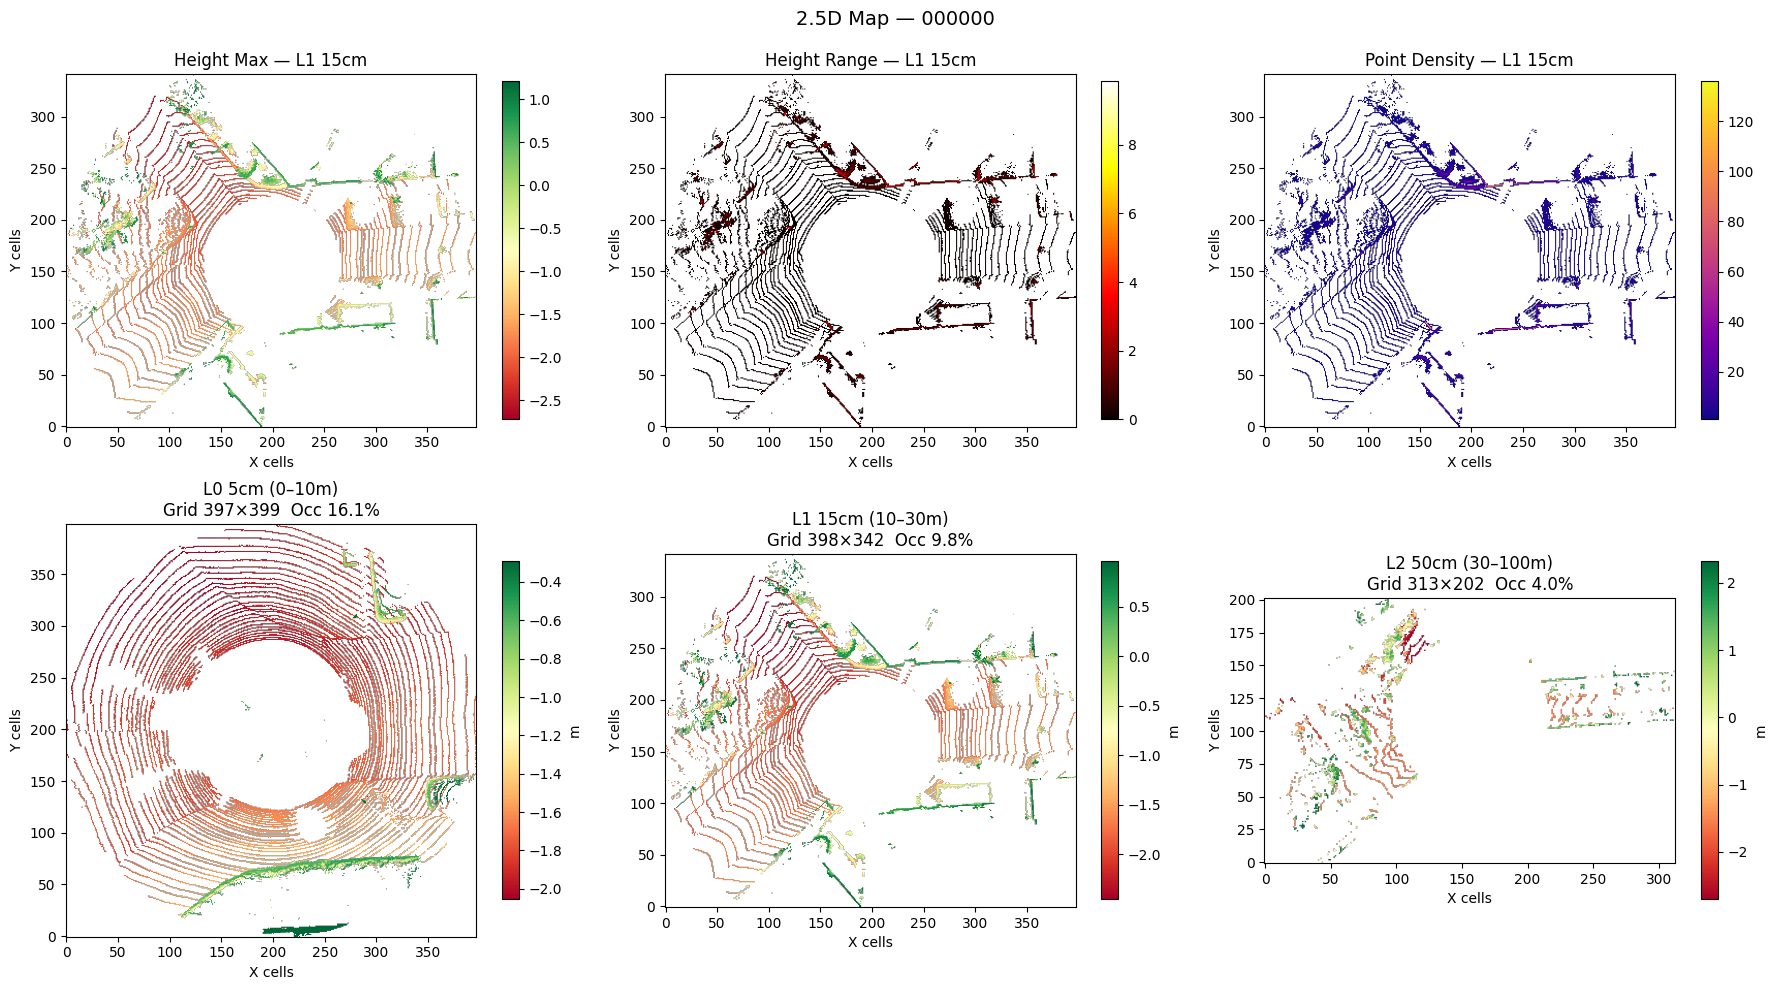

  Saved plot → /content/maps_2d/000000_map2d.png


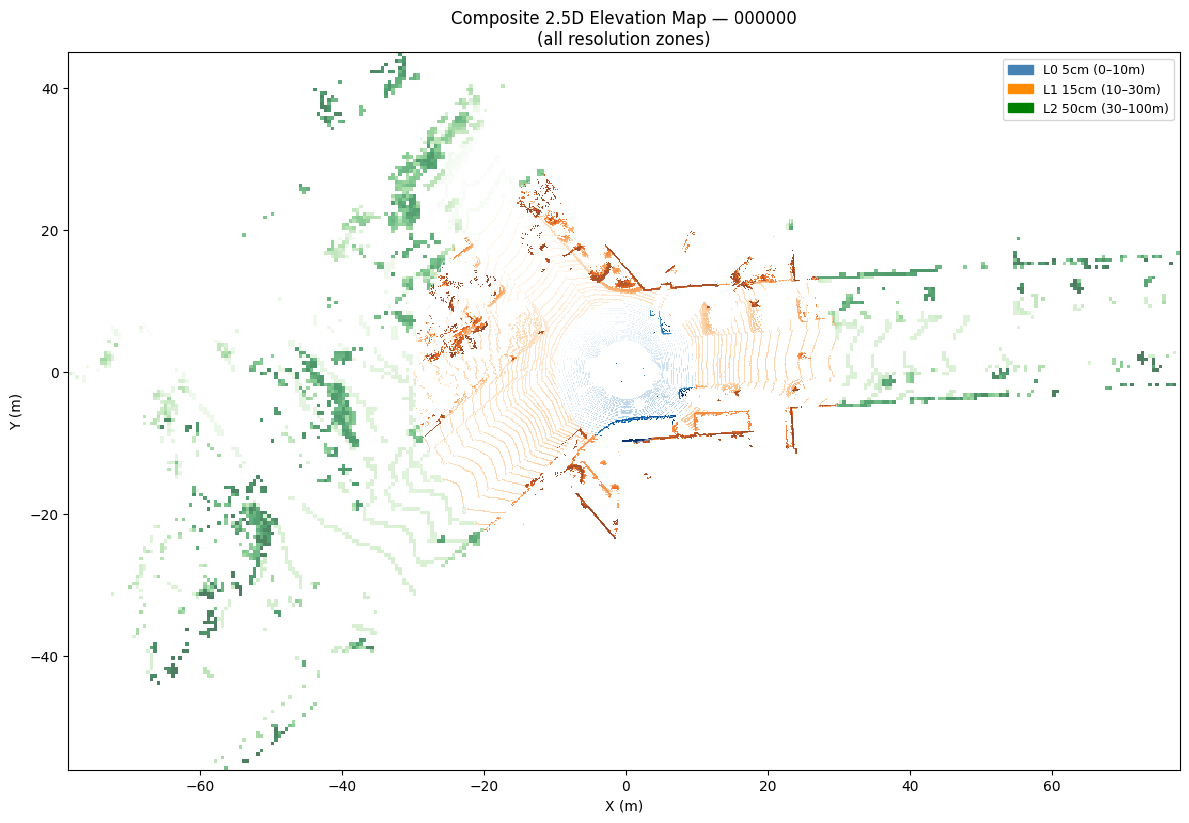

  Saved composite → /content/maps_2d/000000_composite.png

SUMMARY
  Avg projection time : 18.7 ms
  Avg FPS             : 53.6
  Min FPS             : 47.3
  Max FPS             : 56.2

  Avg L0 occupancy    : 15.8%
  Avg L1 occupancy    : 10.0%
  Avg L2 occupancy    : 4.2%

  Voxelization FPS    : ~13.0
  Projection FPS      : 53.6
  Combined estimate   : 10.5 FPS

  Map storage (10 frames) : 7370.7 KB = 7.20 MB
  Avg per frame           : 737.1 KB

Maps saved to: /content/maps_2d


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import time

# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
SAVE_DIR    = "/content/voxel_store"
MAP_DIR     = "/content/maps_2d"
os.makedirs(MAP_DIR, exist_ok=True)

SIZE_MAP    = np.array([0.05, 0.15, 0.50], dtype=np.float32)
LEVEL_NAMES = {0: "L0_5cm", 1: "L1_15cm", 2: "L2_50cm"}

# Feature channel indices inside the grid array
CH = {
    "height_max":   0,
    "height_min":   1,
    "height_range": 2,
    "height_mean":  3,
    "point_count":  4,
    "voxel_count":  5,
    "intensity":    6,
    "is_occupied":  7,
    "pts_per_m2":   8,
}
N_CHANNELS = len(CH)

FILES = [
    f"/content/sematic_kitti_sample/{i:06d}.bin"
    for i in range(10)
]


# ─────────────────────────────────────────
# LOAD SAVED VOXELS
# ─────────────────────────────────────────
def load_voxels(frame_id, save_dir):
    path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
    d    = np.load(path)
    return {
        "unique_keys":    d["keys"],
        "levels":         d["levels"],
        "vox_size":       d["vox_size"],
        "center_x":       d["center_xyz"][:, 0],
        "center_y":       d["center_xyz"][:, 1],
        "center_z":       d["center_xyz"][:, 2],
        "point_count":    d["point_count"],
        "height_mean":    d["height_mean"],
        "height_min":     d["height_min"],
        "height_max":     d["height_max"],
        "height_var":     d["height_var"],
        "height_range":   d["height_range"],
        "intensity_mean": d["intensity"],
    }


# ─────────────────────────────────────────
# PRECOMPUTE — masks, grid bounds, flat indices
# Done once per frame across all levels.
# ─────────────────────────────────────────
def precompute_level_data(features):
    """
    Returns a dict keyed by level (0,1,2).
    Each value contains everything project_level needs,
    computed in a single pass over the features arrays.
    """
    levels_arr = features["levels"]
    cx_all     = features["center_x"]
    cy_all     = features["center_y"]

    level_data = {}
    for lv in [0, 1, 2]:
        mask = levels_arr == lv
        if mask.sum() == 0:
            level_data[lv] = None
            continue

        vs = SIZE_MAP[lv]
        cx = cx_all[mask]
        cy = cy_all[mask]

        ix = np.floor(cx / vs).astype(np.int32)
        iy = np.floor(cy / vs).astype(np.int32)

        ix_min = ix.min()
        iy_min = iy.min()
        ix_rel = ix - ix_min
        iy_rel = iy - iy_min

        H = int(ix_rel.max()) + 1
        W = int(iy_rel.max()) + 1

        flat = (ix_rel * W + iy_rel).astype(np.int64)

        level_data[lv] = {
            "mask":   mask,
            "H":      H,
            "W":      W,
            "flat":   flat,
            "vs":     float(vs),
            "ix_min": int(ix_min),
            "iy_min": int(iy_min),
        }

    return level_data


# ─────────────────────────────────────────
# CORE PROJECTION — reduceat-based, no Python scatter loops
# ─────────────────────────────────────────
def project_level(features, lv_data, level):
    """
    Project all voxels of one level into a 2D grid.
    Returns (grid, meta) where grid has shape (H, W, N_CHANNELS).

    Aggregation per cell:
      height_max   → max of voxel height_max
      height_min   → min of voxel height_min
      height_range → cell height_max - cell height_min  (recomputed)
      height_mean  → point-weighted mean
      point_count  → sum
      voxel_count  → count of contributing voxels
      intensity    → point-weighted mean
      is_occupied  → 1 if any voxel contributes
      pts_per_m2   → point_count / cell_area
    """
    if lv_data is None:
        return None, None

    H        = lv_data["H"]
    W        = lv_data["W"]
    flat     = lv_data["flat"]
    vs       = lv_data["vs"]
    ix_min   = lv_data["ix_min"]
    iy_min   = lv_data["iy_min"]
    mask     = lv_data["mask"]
    C        = H * W
    cell_area = vs * vs

    # ── extract masked source arrays ─────────────────────
    h_max   = features["height_max"][mask].astype(np.float32)
    h_min   = features["height_min"][mask].astype(np.float32)
    h_mean  = features["height_mean"][mask].astype(np.float32)
    pcount  = features["point_count"][mask].astype(np.float32)
    inten   = features["intensity_mean"][mask].astype(np.float32)

    # ── sort once by flat cell index ──────────────────────
    order    = np.argsort(flat, kind="stable")
    flat_s   = flat[order]
    h_max_s  = h_max[order]
    h_min_s  = h_min[order]
    h_mean_s = h_mean[order]
    pcount_s = pcount[order]
    inten_s  = inten[order]

    # Group boundaries: where the cell index changes
    diff     = np.diff(flat_s)
    splits   = np.flatnonzero(diff) + 1          # positions of group starts (excl. 0)
    starts   = np.r_[0, splits]                  # include group 0

    unique_cells = flat_s[starts]                # which cells are occupied

    # ── reduceat aggregations (all O(N), no Python loops) ─
    g_hmax_occ  = np.maximum.reduceat(h_max_s,  starts)
    g_hmin_occ  = np.minimum.reduceat(h_min_s,  starts)
    g_pcount_occ = np.add.reduceat(pcount_s,    starts)
    g_vcount_occ = np.add.reduceat(
                       np.ones(len(flat_s), dtype=np.float32), starts)
    g_hmean_num  = np.add.reduceat(h_mean_s * pcount_s, starts)
    g_inten_num  = np.add.reduceat(inten_s  * pcount_s, starts)

    # Point-weighted means
    g_hmean_occ = g_hmean_num / g_pcount_occ
    g_inten_occ = g_inten_num / g_pcount_occ

    # Height range recomputed from aggregated min/max
    g_hrange_occ = g_hmax_occ - g_hmin_occ

    # pts/m²
    g_pts_m2_occ = g_pcount_occ / cell_area

    # ── scatter occupied results into full C-length arrays ─
    # (only occupied cells get written; empty cells stay 0)
    g_hmax   = np.zeros(C, dtype=np.float32)
    g_hmin   = np.zeros(C, dtype=np.float32)
    g_hrange = np.zeros(C, dtype=np.float32)
    g_hmean  = np.zeros(C, dtype=np.float32)
    g_pcount = np.zeros(C, dtype=np.float32)
    g_vcount = np.zeros(C, dtype=np.float32)
    g_inten  = np.zeros(C, dtype=np.float32)
    g_occ    = np.zeros(C, dtype=np.float32)
    g_pts_m2 = np.zeros(C, dtype=np.float32)

    uc = unique_cells  # occupied flat indices (no repeats)
    g_hmax[uc]   = g_hmax_occ
    g_hmin[uc]   = g_hmin_occ
    g_hrange[uc] = g_hrange_occ
    g_hmean[uc]  = g_hmean_occ
    g_pcount[uc] = g_pcount_occ
    g_vcount[uc] = g_vcount_occ
    g_inten[uc]  = g_inten_occ
    g_occ[uc]    = 1.0
    g_pts_m2[uc] = g_pts_m2_occ

    # ── pack directly into (H, W, N_CHANNELS) ────────────
    grid = np.zeros((H, W, N_CHANNELS), dtype=np.float32)
    grid[:, :, CH["height_max"]]   = g_hmax.reshape(H, W)
    grid[:, :, CH["height_min"]]   = g_hmin.reshape(H, W)
    grid[:, :, CH["height_range"]] = g_hrange.reshape(H, W)
    grid[:, :, CH["height_mean"]]  = g_hmean.reshape(H, W)
    grid[:, :, CH["point_count"]]  = g_pcount.reshape(H, W)
    grid[:, :, CH["voxel_count"]]  = g_vcount.reshape(H, W)
    grid[:, :, CH["intensity"]]    = g_inten.reshape(H, W)
    grid[:, :, CH["is_occupied"]]  = g_occ.reshape(H, W)
    grid[:, :, CH["pts_per_m2"]]   = g_pts_m2.reshape(H, W)

    n_occ = len(unique_cells)
    meta = {
        "level":     level,
        "H":         H,
        "W":         W,
        "vox_size":  vs,
        "ix_min":    ix_min,
        "iy_min":    iy_min,
        "n_voxels":  int(mask.sum()),
        "occupied":  n_occ,
        "x_range_m": (float(ix_min * vs), float((ix_min + H) * vs)),
        "y_range_m": (float(iy_min * vs), float((iy_min + W) * vs)),
    }
    return grid, meta


def project_2d(features):
    """
    Project all three levels.
    Bounds and masks are precomputed once, then each level projects.
    Returns (grids, metas).
    """
    level_data = precompute_level_data(features)

    grids = {}
    metas = {}
    for lv in [0, 1, 2]:
        grid, meta = project_level(features, level_data[lv], lv)
        if grid is not None:
            grids[lv] = grid
            metas[lv] = meta
    return grids, metas


# ─────────────────────────────────────────
# SAVE / LOAD
# ─────────────────────────────────────────
def save_maps(grids, metas, frame_id, map_dir):
    out = {}
    for lv, grid in grids.items():
        out[LEVEL_NAMES[lv]] = grid
    meta_arr = np.array(
        [[metas[lv]["H"], metas[lv]["W"],
          metas[lv]["ix_min"], metas[lv]["iy_min"]]
         for lv in sorted(metas.keys())],
        dtype=np.int32,
    )
    out["meta_hwoff"] = meta_arr
    path = os.path.join(map_dir, f"{frame_id}_map2d.npz")
    np.savez_compressed(path, **out)
    return path


def load_maps(frame_id, map_dir):
    path  = os.path.join(map_dir, f"{frame_id}_map2d.npz")
    d     = np.load(path)
    return {
        0: d["L0_5cm"],
        1: d["L1_15cm"],
        2: d["L2_50cm"],
    }


# ─────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────
def visualize_map(grids, metas, frame_id, map_dir):
    """
    6-panel visualization:
      Row 0: height_max, height_range, point_density  (L1)
      Row 1: L0 / L1 / L2 elevation side by side
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"2.5D Map — {frame_id}", fontsize=14)

    level_labels = [
        "L0 5cm (0–10m)",
        "L1 15cm (10–30m)",
        "L2 50cm (30–100m)",
    ]

    def plot_channel(ax, lv, ch_name, title, cmap):
        grid = grids[lv]
        occ  = grid[:, :, CH["is_occupied"]].astype(bool)
        data = grid[:, :, CH[ch_name]].copy()
        data[~occ] = np.nan
        im = ax.imshow(data.T, origin="lower", cmap=cmap, aspect="equal")
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(title)
        ax.set_xlabel("X cells")
        ax.set_ylabel("Y cells")

    plot_channel(axes[0, 0], 1, "height_max",   "Height Max — L1 15cm",   "RdYlGn")
    plot_channel(axes[0, 1], 1, "height_range", "Height Range — L1 15cm", "hot")
    plot_channel(axes[0, 2], 1, "point_count",  "Point Density — L1 15cm","plasma")

    for col, lv in enumerate([0, 1, 2]):
        ax   = axes[1, col]
        grid = grids[lv]
        meta = metas[lv]
        occ  = grid[:, :, CH["is_occupied"]].astype(bool)
        hmax = grid[:, :, CH["height_max"]].copy()
        hmax[~occ] = np.nan

        vmin = np.nanpercentile(hmax, 2)
        vmax = np.nanpercentile(hmax, 98)
        im   = ax.imshow(hmax.T, origin="lower", cmap="RdYlGn",
                         vmin=vmin, vmax=vmax, aspect="equal")
        plt.colorbar(im, ax=ax, shrink=0.8, label="m")

        occ_pct = meta["occupied"] / (meta["H"] * meta["W"]) * 100
        ax.set_title(
            f"{level_labels[lv]}\n"
            f"Grid {meta['H']}×{meta['W']}  Occ {occ_pct:.1f}%"
        )
        ax.set_xlabel("X cells")
        ax.set_ylabel("Y cells")

    plt.tight_layout()
    path = os.path.join(map_dir, f"{frame_id}_map2d.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved plot → {path}")


def visualize_composite(grids, metas, frame_id, map_dir):
    """
    Single composite top-down view combining all three levels.
    Shows physical coordinates in metres.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    ax.set_title(
        f"Composite 2.5D Elevation Map — {frame_id}\n"
        f"(all resolution zones)"
    )

    cmaps  = ["Blues", "Oranges", "Greens"]
    alphas = [1.0, 0.85, 0.7]

    for lv in [2, 1, 0]:           # coarse → fine (fine drawn on top)
        grid = grids[lv]
        meta = metas[lv]
        vs   = meta["vox_size"]
        occ  = grid[:, :, CH["is_occupied"]].astype(bool)
        hmax = grid[:, :, CH["height_max"]].copy()
        hmax[~occ] = np.nan

        x0 = meta["ix_min"] * vs
        x1 = (meta["ix_min"] + meta["H"]) * vs
        y0 = meta["iy_min"] * vs
        y1 = (meta["iy_min"] + meta["W"]) * vs

        vmin = np.nanpercentile(hmax, 2)
        vmax = np.nanpercentile(hmax, 98)

        ax.imshow(
            hmax.T,
            origin="lower",
            extent=[x0, x1, y0, y1],
            cmap=cmaps[lv],
            vmin=vmin, vmax=vmax,
            alpha=alphas[lv],
            aspect="equal",
            interpolation="nearest",
        )

    theta = np.linspace(0, 2 * np.pi, 360)
    for r, label in [(10, "10m"), (30, "30m")]:
        ax.plot(r * np.cos(theta), r * np.sin(theta),
                "w--", linewidth=1, alpha=0.6)
        ax.text(r * 0.7, r * 0.7, label,
                color="white", fontsize=8, alpha=0.8)

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")

    from matplotlib.patches import Patch
    legend = [
        Patch(color="steelblue",  label="L0 5cm (0–10m)"),
        Patch(color="darkorange", label="L1 15cm (10–30m)"),
        Patch(color="green",      label="L2 50cm (30–100m)"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)

    path = os.path.join(map_dir, f"{frame_id}_composite.png")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved composite → {path}")


# ─────────────────────────────────────────
# QUALITY CHECK
# ─────────────────────────────────────────
def map_quality_report(grids, metas):
    print("\n── 2.5D Map Quality Report ──")
    for lv in [0, 1, 2]:
        grid   = grids[lv]
        meta   = metas[lv]
        occ    = grid[:, :, CH["is_occupied"]].astype(bool)
        hmax   = grid[:, :, CH["height_max"]]
        hmin   = grid[:, :, CH["height_min"]]
        hrange = grid[:, :, CH["height_range"]]
        pcount = grid[:, :, CH["point_count"]]
        pts_m2 = grid[:, :, CH["pts_per_m2"]]

        total_cells = meta["H"] * meta["W"]
        occ_cells   = occ.sum()
        occ_pct     = occ_cells / total_cells * 100

        print(f"\n  {LEVEL_NAMES[lv]}")
        print(f"    Grid size     : {meta['H']} × {meta['W']} = {total_cells:,} cells")
        print(f"    Occupied      : {occ_cells:,} ({occ_pct:.1f}%)")
        print(f"    X range       : {meta['x_range_m'][0]:.1f} – {meta['x_range_m'][1]:.1f} m")
        print(f"    Y range       : {meta['y_range_m'][0]:.1f} – {meta['y_range_m'][1]:.1f} m")
        print(f"    height_max    : min={hmax[occ].min():.2f}  "
              f"mean={hmax[occ].mean():.2f}  max={hmax[occ].max():.2f} m")
        print(f"    height_range  : min={hrange[occ].min():.3f}  "
              f"mean={hrange[occ].mean():.3f}  max={hrange[occ].max():.3f} m")
        print(f"    pts/m²        : mean={pts_m2[occ].mean():.1f}  max={pts_m2[occ].max():.1f}")

        # Correctness: stronger check than just height_range >= 0
        bad_order = (hmin[occ] > hmax[occ] + 1e-4).sum()
        neg_range = (hrange[occ] < -1e-4).sum()
        print(f"    ✓ height_min > height_max : {bad_order} "
              f"{'✓' if bad_order == 0 else '✗ WARNING'}")
        print(f"    ✓ Negative height_range   : {neg_range} "
              f"{'✓' if neg_range == 0 else '✗ WARNING'}")


# ─────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────
print("=" * 80)
print(f"{'Frame':<12} {'L0 grid':>12} {'L1 grid':>12} "
      f"{'L2 grid':>12} {'Proj ms':>10} {'FPS':>6}")
print("-" * 80)

all_results = []

for fpath in FILES:
    fname    = os.path.basename(fpath)
    fid      = os.path.splitext(fname)[0]
    features = load_voxels(fid, SAVE_DIR)

    t0            = time.perf_counter()
    grids, metas  = project_2d(features)
    proj_ms       = (time.perf_counter() - t0) * 1000

    map_path = save_maps(grids, metas, fid, MAP_DIR)

    l0 = metas[0]
    l1 = metas[1]
    l2 = metas[2]

    result = dict(
        frame   = fid,
        proj_ms = proj_ms,
        fps     = 1000 / proj_ms,
        l0_hw   = (l0["H"], l0["W"]),
        l1_hw   = (l1["H"], l1["W"]),
        l2_hw   = (l2["H"], l2["W"]),
        l0_occ  = l0["occupied"] / (l0["H"] * l0["W"]) * 100,
        l1_occ  = l1["occupied"] / (l1["H"] * l1["W"]) * 100,
        l2_occ  = l2["occupied"] / (l2["H"] * l2["W"]) * 100,
    )
    all_results.append(result)

    print(f"{fname:<12} "
          f"{l0['H']}×{l0['W']:>6} "
          f"{l1['H']}×{l1['W']:>6} "
          f"{l2['H']}×{l2['W']:>6} "
          f"{proj_ms:>9.1f}ms "
          f"{1000/proj_ms:>5.1f}")

# ── quality + visuals for frame 0 ────────────────────────
print("\nRunning quality report and visualization on 000000...")
features_0       = load_voxels("000000", SAVE_DIR)
grids_0, metas_0 = project_2d(features_0)
map_quality_report(grids_0, metas_0)
visualize_map(grids_0, metas_0, "000000", MAP_DIR)
visualize_composite(grids_0, metas_0, "000000", MAP_DIR)

# ── summary ──────────────────────────────────────────────
def avg(k):
    return np.mean([r[k] for r in all_results])

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"  Avg projection time : {avg('proj_ms'):.1f} ms")
print(f"  Avg FPS             : {avg('fps'):.1f}")
print(f"  Min FPS             : {min(r['fps'] for r in all_results):.1f}")
print(f"  Max FPS             : {max(r['fps'] for r in all_results):.1f}")
print(f"\n  Avg L0 occupancy    : {avg('l0_occ'):.1f}%")
print(f"  Avg L1 occupancy    : {avg('l1_occ'):.1f}%")
print(f"  Avg L2 occupancy    : {avg('l2_occ'):.1f}%")

print(f"\n  Voxelization FPS    : ~13.0")
print(f"  Projection FPS      : {avg('fps'):.1f}")
print(f"  Combined estimate   : {1000 / (1000/13 + avg('proj_ms')):.1f} FPS")

total_kb = sum(
    os.path.getsize(
        os.path.join(MAP_DIR, f"{r['frame']}_map2d.npz")
    ) / 1024
    for r in all_results
)
print(f"\n  Map storage (10 frames) : {total_kb:.1f} KB = {total_kb/1024:.2f} MB")
print(f"  Avg per frame           : {total_kb/len(all_results):.1f} KB")
print(f"\nMaps saved to: {MAP_DIR}")

SEMANTIC LABEL PIPELINE
Frame          Voxels   Cells L0   Cells L1   Cells L2       ms    FPS
--------------------------------------------------------------------------------
000000.bin     62,158     23,665     13,274      2,469   239.4ms   4.2
000001.bin     62,256     23,752     13,081      2,436   233.1ms   4.3
000002.bin     62,134     23,516     12,693      2,440   304.7ms   3.3
000003.bin     61,926     23,507     12,358      2,326   337.2ms   3.0
000004.bin     61,899     23,454     12,227      2,345   345.8ms   2.9
000005.bin     61,519     23,360     11,996      2,368   335.6ms   3.0
000006.bin     60,909     23,038     11,659      2,323   343.7ms   2.9
000007.bin     60,534     22,961     11,516      2,332   330.4ms   3.0
000008.bin     60,278     23,020     11,095      2,368   219.0ms   4.6
000009.bin     60,434     22,881     10,789      2,385   221.7ms   4.5

Running quality report and visualization on 000000...

LABEL QUALITY REPORT

── Voxel labels (62,158 voxels) ──
 

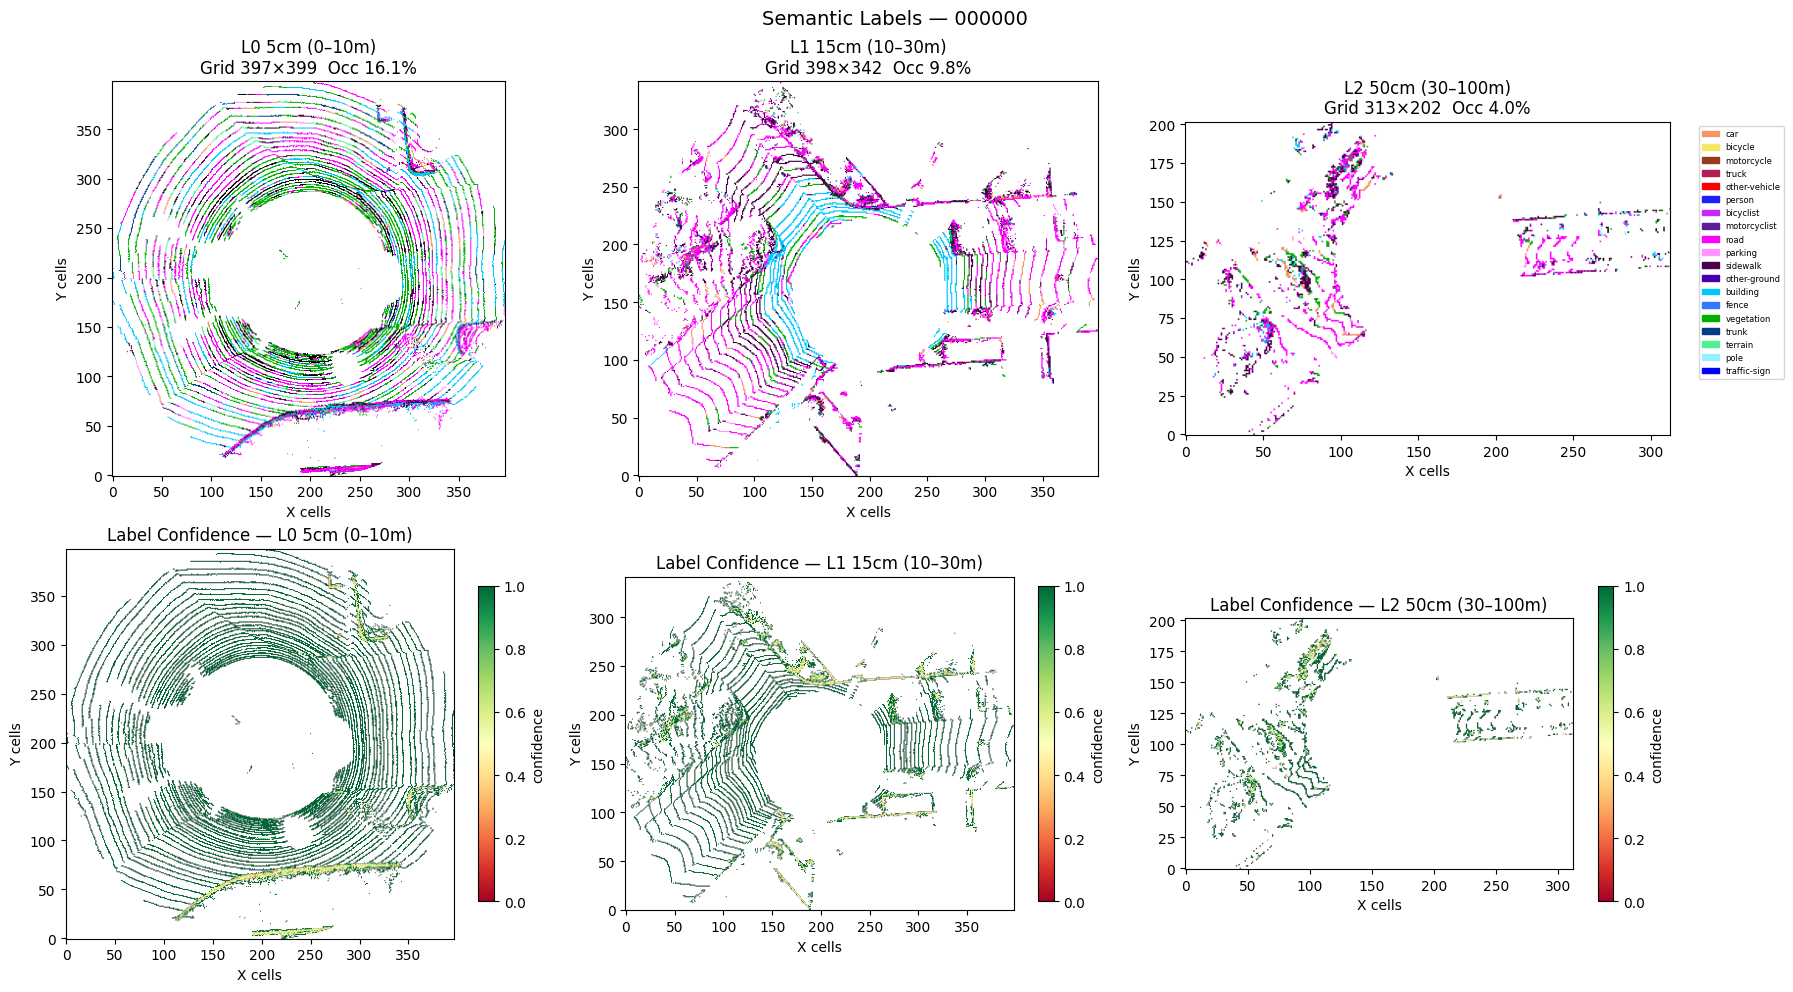

  Saved semantic map → /content/label_store/000000_semantic.png


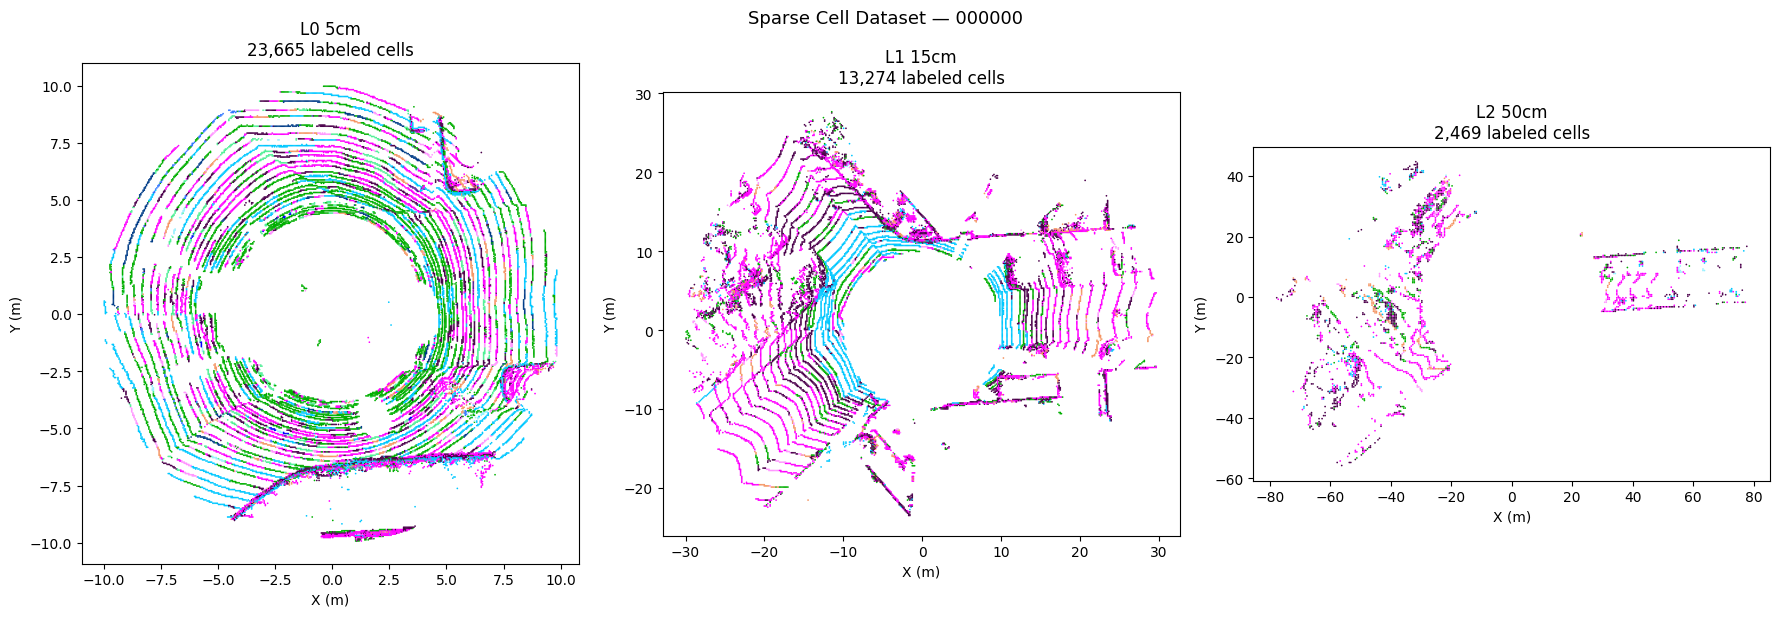

  Saved sparse viz → /content/sparse_store/000000_sparse_viz.png

SPARSE DATASET SUMMARY
  Frames processed : 10

  Total labeled cells : 377,634
    L0 5cm            : 233,154
    L1 15cm           : 120,688
    L2 50cm           : 23,792

  Class distribution across all frames:
    road                 :  103,639  ( 27.4%)
    vegetation           :   81,838  ( 21.7%)
    building             :   73,243  ( 19.4%)
    sidewalk             :   68,165  ( 18.1%)
    car                  :   17,428  (  4.6%)
    parking              :   14,405  (  3.8%)
    terrain              :    8,428  (  2.2%)
    trunk                :    5,745  (  1.5%)
    fence                :    2,453  (  0.6%)
    pole                 :    1,653  (  0.4%)
    motorcyclist         :      343  (  0.1%)
    traffic-sign         :      288  (  0.1%)
    other-vehicle        :        3  (  0.0%)
    person               :        3  (  0.0%)

── Timing ──
  Avg label pipeline   : 291.0 ms  (3.4 FPS)
  (Labels are a

In [10]:
# -*- coding: utf-8 -*-
"""
semantic_labels.py
──────────────────
Stage 3 of the adaptive voxelization pipeline.

What this module does
─────────────────────
  Raw LiDAR + .label files
        ↓
  point-level semantic class  (SemanticKITTI uint32 format)
        ↓
  voxel-level majority class  (same inverse index from VoxelPipeline)
        ↓
  2D-cell majority class       (same flat index from project_level)
        ↓
  sparse cell dataset          (coords, features, labels) ready for CNN

Outputs
───────
  *_labels.npz   — per-voxel and per-cell semantic labels + confidence
  *_sparse.npz   — sparse (coords, features, label) per level
  label_dataset_meta.json — summary across all frames

Usage (Colab)
─────────────
  Run after adaptive_voxelization.py has populated:
    /content/voxel_store/   (voxel .npz files)
    /content/maps_2d/       (map .npz files)

  Label files are expected at:
    /content/semantic_kitti_sample/{frame_id}.label

  To download them alongside the .bin files, add to the Kaggle loop:
    filename = f"dataset/sequences/00/labels/{i:06d}.label"
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import json
import time

# ─────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────
SAMPLE_DIR  = "/content/semantic_kitti_sample"
SAVE_DIR    = "/content/voxel_store"
MAP_DIR     = "/content/maps_2d"
LABEL_DIR = "/content/label_store"
SPARSE_DIR  = "/content/sparse_store"

os.makedirs(LABEL_DIR,  exist_ok=True)
os.makedirs(SPARSE_DIR, exist_ok=True)

SIZE_MAP = np.array([0.05, 0.15, 0.50], dtype=np.float32)

FILES = [f"/content/semantic_kitti_sample/{i:06d}.bin" for i in range(10)]

# Feature channel map — must match adaptive_voxelization.py exactly
CH = {
    "height_max":   0,
    "height_min":   1,
    "height_range": 2,
    "height_mean":  3,
    "point_count":  4,
    "voxel_count":  5,
    "intensity":    6,
    "is_occupied":  7,
    "pts_per_m2":   8,
}
N_CHANNELS = len(CH)


# ─────────────────────────────────────────────────────────────────
# SEMANTICKITTI CLASS DEFINITIONS
# ─────────────────────────────────────────────────────────────────
# Raw label IDs from the dataset.  SemanticKITTI uses the lower 16
# bits of the uint32; upper 16 bits are the instance ID.
# We remap to a compact set of 20 learning classes (0–19).
# Class 0 is "unlabeled / ignore".

RAW_TO_LEARNING = {
    0:   0,   # unlabeled
    1:   0,   # outlier → ignore
    10:  1,   # car
    11:  2,   # bicycle
    13:  5,   # bus
    15:  3,   # motorcycle
    16:  5,   # on-rails → bus
    18:  4,   # truck
    20:  5,   # other-vehicle
    30:  6,   # person
    31:  7,   # bicyclist
    32:  8,   # motorcyclist
    40:  9,   # road
    44: 10,   # parking
    48: 11,   # sidewalk
    49: 12,   # other-ground
    50: 13,   # building
    51: 14,   # fence
    52:  0,   # other-structure → ignore
    60:  9,   # lane-marking → road
    70: 15,   # vegetation
    71: 16,   # trunk
    72: 17,   # terrain
    80: 18,   # pole
    81: 19,   # traffic-sign
    99:  0,   # other-object → ignore
    252:  1,  # moving-car
    253:  7,  # moving-bicyclist
    254:  6,  # moving-person
    255:  8,  # moving-motorcyclist
    256:  5,  # moving-on-rails
    257:  5,  # moving-bus
    258:  4,  # moving-truck
    259:  5,  # moving-other-vehicle
}

CLASS_NAMES = {
     0: "unlabeled",
     1: "car",
     2: "bicycle",
     3: "motorcycle",
     4: "truck",
     5: "other-vehicle",
     6: "person",
     7: "bicyclist",
     8: "motorcyclist",
     9: "road",
    10: "parking",
    11: "sidewalk",
    12: "other-ground",
    13: "building",
    14: "fence",
    15: "vegetation",
    16: "trunk",
    17: "terrain",
    18: "pole",
    19: "traffic-sign",
}

# Colour palette for visualisation (one RGB per learning class)
CLASS_COLORS = np.array([
    [0,   0,   0  ],   #  0 unlabeled    — black
    [245, 150, 100],   #  1 car          — orange
    [245, 230, 100],   #  2 bicycle      — yellow
    [150, 60,  30 ],   #  3 motorcycle   — brown
    [180, 30,  80 ],   #  4 truck        — dark red
    [255, 0,   0  ],   #  5 other-veh    — red
    [30,  30,  255],   #  6 person       — blue
    [200, 40,  255],   #  7 bicyclist    — purple
    [90,  30,  150],   #  8 motorcyclist — dark purple
    [255, 0,   255],   #  9 road         — magenta
    [255, 150, 255],   # 10 parking      — light magenta
    [75,  0,   75 ],   # 11 sidewalk     — dark magenta
    [75,  0,   175],   # 12 other-ground — indigo
    [0,   200, 255],   # 13 building     — cyan
    [50,  120, 255],   # 14 fence        — light blue
    [0,   175, 0  ],   # 15 vegetation   — green
    [0,   60,  135],   # 16 trunk        — dark blue-green
    [80,  240, 150],   # 17 terrain      — light green
    [150, 240, 255],   # 18 pole         — ice blue
    [0,   0,   255],   # 19 traffic-sign — pure blue
], dtype=np.uint8)

N_CLASSES = len(CLASS_NAMES)  # 20


# ─────────────────────────────────────────────────────────────────
# I/O HELPERS
# ─────────────────────────────────────────────────────────────────
def load_points(path):
    return np.fromfile(path, dtype=np.float32).reshape(-1, 4)


def load_labels(bin_path):
    """
    Load .label file and remap raw SemanticKITTI IDs → learning classes 0–19.
    Expects labels at: /content/semantic_kitti_sample/{frame_id}.label
    """
    fid        = os.path.basename(bin_path).replace(".bin", "")
    label_path = os.path.join(SAMPLE_DIR, f"{fid}.label")

    if not os.path.exists(label_path):
        raise FileNotFoundError(f"Label file not found: {label_path}")

    raw = np.fromfile(label_path, dtype=np.uint32)
    sem = (raw & 0xFFFF).astype(np.int32)          # lower 16 bits = semantic ID

    # Validate point/label count matches
    n_points = len(np.fromfile(bin_path, dtype=np.float32)) // 4
    if len(sem) != n_points:
        raise ValueError(
            f"Point/label mismatch for {fid}: "
            f"{n_points} points vs {len(sem)} labels"
        )

    # Build LUT: raw semantic ID → learning class (0–19)
    # IDs not in RAW_TO_LEARNING map to 0 (unlabeled/ignore)
    lut = np.zeros(max(RAW_TO_LEARNING.keys()) + 1, dtype=np.uint8)
    for raw_id, learn_id in RAW_TO_LEARNING.items():
        lut[raw_id] = learn_id

    clipped = np.clip(sem, 0, len(lut) - 1)
    return lut[clipped]                             # (N,) uint8, values 0–19


def load_voxels(frame_id, save_dir):
    path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
    d    = np.load(path)
    return {
        "unique_keys":    d["keys"],
        "levels":         d["levels"],
        "vox_size":       d["vox_size"],
        "center_x":       d["center_xyz"][:, 0],
        "center_y":       d["center_xyz"][:, 1],
        "center_z":       d["center_xyz"][:, 2],
        "point_count":    d["point_count"],
        "height_mean":    d["height_mean"],
        "height_min":     d["height_min"],
        "height_max":     d["height_max"],
        "height_var":     d["height_var"],
        "height_range":   d["height_range"],
        "intensity_mean": d["intensity"],
    }


def load_maps(frame_id, map_dir):
    path = os.path.join(map_dir, f"{frame_id}_map2d.npz")
    d    = np.load(path)
    # meta_hwoff shape: (3, 4) — [H, W, ix_min, iy_min] per level
    meta_arr = d["meta_hwoff"]
    grids = {0: d["L0_5cm"], 1: d["L1_15cm"], 2: d["L2_50cm"]}
    metas = {}
    for i, lv in enumerate([0, 1, 2]):
        H, W, ix_min, iy_min = meta_arr[i]
        vs = float(SIZE_MAP[lv])
        metas[lv] = {
            "H": int(H), "W": int(W),
            "ix_min": int(ix_min), "iy_min": int(iy_min),
            "vox_size": vs,
            "x_range_m": (ix_min * vs, (ix_min + H) * vs),
            "y_range_m": (iy_min * vs, (iy_min + W) * vs),
        }
    return grids, metas


# ─────────────────────────────────────────────────────────────────
# STEP 1 — POINT LABELS → VOXEL LABELS
# ─────────────────────────────────────────────────────────────────
def assign_voxel_labels(points, point_labels, features):
    """
    For each voxel, find the majority semantic class of its member points.

    Strategy
    ────────
    VoxelPipeline already computed the (inverse) mapping that tells us
    which voxel index each point belongs to.  We replicate the same
    key construction here to recover that inverse array, then use
    np.add.reduceat on one-hot class counts to get per-voxel histograms
    in a single vectorised pass.

    Returns
    ───────
    voxel_class      : (V,) uint8  — majority class per voxel
    voxel_confidence : (V,) float32 — fraction of points that voted for it
    voxel_class_hist : (V, N_CLASSES) uint16 — full vote histogram
    """
    N = len(points)
    x = points[:, 0];  y = points[:, 1]

    # ── replicate level/key assignment (same logic as VoxelPipeline) ──
    dist     = np.sqrt(x * x + y * y)
    levels   = np.where(dist < 10, np.int32(0),
               np.where(dist < 30, np.int32(1),
                                   np.int32(2)))
    vox_size = SIZE_MAP[levels]

    coords = np.floor(
        points[:, :3] / vox_size[:, None]
    ).astype(np.int32)

    keys_c = np.ascontiguousarray(
        np.stack([levels, coords[:, 0], coords[:, 1], coords[:, 2]], axis=1)
    )
    keys_v = keys_c.view(
        np.dtype((np.void, keys_c.dtype.itemsize * 4))
    ).ravel()

    unique_void, inverse = np.unique(keys_v, return_inverse=True)
    unique_keys_check    = unique_void.view(np.int32).reshape(-1, 4)
    V = len(unique_keys_check)

    # Sanity: ensure key order matches saved features
    # (they will match because np.unique is deterministic on identical input)
    saved_keys = features["unique_keys"]
    if not np.array_equal(unique_keys_check, saved_keys):
        raise RuntimeError(
            "Voxel key mismatch between label assignment and saved features. "
            "Ensure points and features come from the same frame."
        )

    # ── sort points by voxel index ────────────────────────────────
    order      = np.argsort(inverse, kind="stable")
    inv_sorted = inverse[order]
    lbl_sorted = point_labels[order].astype(np.int32)

    diff   = np.diff(inv_sorted)
    splits = np.flatnonzero(diff) + 1
    starts = np.r_[0, splits]          # (V,)

    # ── per-voxel class histogram via one-hot reduceat ────────────
    # Build a (N, N_CLASSES) one-hot matrix, then reduceat-sum each column.
    # For N=125k and N_CLASSES=20 this is a 125k×20 float32 array (~10 MB).
    one_hot = np.zeros((N, N_CLASSES), dtype=np.float32)
    one_hot[np.arange(N), lbl_sorted] = 1.0

    # reduceat each class column independently — V reductions of ~125k/V pts
    hist = np.zeros((V, N_CLASSES), dtype=np.float32)
    for c in range(N_CLASSES):
        hist[:, c] = np.add.reduceat(one_hot[order, c], starts)

    hist_int = hist.astype(np.uint16)                   # save as uint16

    # ── majority vote ─────────────────────────────────────────────
    voxel_class      = np.argmax(hist, axis=1).astype(np.uint8)
    total_votes      = hist.sum(axis=1)                 # = point_count
    voxel_confidence = (
        hist[np.arange(V), voxel_class] / np.maximum(total_votes, 1)
    ).astype(np.float32)

    return voxel_class, voxel_confidence, hist_int


# ─────────────────────────────────────────────────────────────────
# STEP 2 — VOXEL LABELS → 2D CELL LABELS
# ─────────────────────────────────────────────────────────────────
def assign_cell_labels(features, voxel_class, voxel_confidence, metas):
    """
    Project voxel labels down to 2D cells per level.

    Aggregation rule
    ────────────────
    When multiple voxels project into the same XY cell, the cell
    label = class with the most total supporting points across those
    voxels.  We approximate this with a point-count-weighted vote:
    each voxel casts `point_count` votes for its class.

    Returns
    ───────
    cell_labels : dict[level → (H, W) uint8]  — per-cell majority class
    cell_conf   : dict[level → (H, W) float32] — confidence
    """
    levels_arr = features["levels"]
    pcount_arr = features["point_count"].astype(np.float32)
    cx_all     = features["center_x"]
    cy_all     = features["center_y"]

    cell_labels = {}
    cell_conf   = {}

    for lv in [0, 1, 2]:
        meta  = metas[lv]
        H, W  = meta["H"], meta["W"]
        vs    = meta["vox_size"]
        ix_min = meta["ix_min"]
        iy_min = meta["iy_min"]

        mask   = levels_arr == lv
        if mask.sum() == 0:
            cell_labels[lv] = np.zeros((H, W), dtype=np.uint8)
            cell_conf[lv]   = np.zeros((H, W), dtype=np.float32)
            continue

        cx = cx_all[mask]
        cy = cy_all[mask]
        vc = voxel_class[mask]
        pc = pcount_arr[mask]

        ix_rel = (np.floor(cx / vs).astype(np.int32) - ix_min)
        iy_rel = (np.floor(cy / vs).astype(np.int32) - iy_min)
        flat   = (ix_rel * W + iy_rel).astype(np.int64)

        # Sort by flat cell index
        order    = np.argsort(flat, kind="stable")
        flat_s   = flat[order]
        vc_s     = vc[order]
        pc_s     = pc[order]

        diff   = np.diff(flat_s)
        splits = np.flatnonzero(diff) + 1
        starts = np.r_[0, splits]
        unique_cells = flat_s[starts]
        n_occ        = len(unique_cells)

        # Weighted histogram per cell
        n_local = len(flat_s)
        one_hot = np.zeros((n_local, N_CLASSES), dtype=np.float32)
        one_hot[np.arange(n_local), vc_s.astype(np.int32)] = pc_s

        hist_occ = np.zeros((n_occ, N_CLASSES), dtype=np.float32)
        for c in range(N_CLASSES):
            hist_occ[:, c] = np.add.reduceat(one_hot[:, c], starts)

        cls_occ  = np.argmax(hist_occ, axis=1).astype(np.uint8)
        tot_occ  = hist_occ.sum(axis=1)
        conf_occ = (
            hist_occ[np.arange(n_occ), cls_occ.astype(np.int32)]
            / np.maximum(tot_occ, 1)
        ).astype(np.float32)

        # Scatter into full grid
        cls_grid  = np.zeros(H * W, dtype=np.uint8)
        conf_grid = np.zeros(H * W, dtype=np.float32)
        cls_grid[unique_cells]  = cls_occ
        conf_grid[unique_cells] = conf_occ

        cell_labels[lv] = cls_grid.reshape(H, W)
        cell_conf[lv]   = conf_grid.reshape(H, W)

    return cell_labels, cell_conf


# ─────────────────────────────────────────────────────────────────
# STEP 3 — BUILD SPARSE DATASET
# ─────────────────────────────────────────────────────────────────
def build_sparse_dataset(grids, metas, cell_labels, cell_conf,
                         ignore_class=0):
    """
    Extract only occupied cells with a valid (non-ignored) label.

    Returns
    ───────
    dataset : dict[level → {coords, features, labels, confidence}]

      coords     : (M, 2) int32   — (ix_rel, iy_rel) cell indices
      features   : (M, N_CHANNELS) float32
      labels     : (M,) uint8
      confidence : (M,) float32
    """
    dataset = {}

    for lv in [0, 1, 2]:
        grid   = grids[lv]                            # (H, W, C)
        labels = cell_labels[lv]                      # (H, W)
        conf   = cell_conf[lv]                        # (H, W)

        occ  = grid[:, :, CH["is_occupied"]].astype(bool)
        valid = occ & (labels != ignore_class)

        if valid.sum() == 0:
            dataset[lv] = None
            continue

        ix, iy = np.where(valid)
        coords     = np.stack([ix, iy], axis=1).astype(np.int32)
        feat       = grid[ix, iy, :]                  # (M, N_CHANNELS)
        lbl        = labels[ix, iy]                   # (M,)
        c          = conf[ix, iy]                     # (M,)

        dataset[lv] = {
            "coords":     coords,
            "features":   feat,
            "labels":     lbl,
            "confidence": c,
            "meta":       metas[lv],
        }

    return dataset


# ─────────────────────────────────────────────────────────────────
# SAVE / LOAD
# ─────────────────────────────────────────────────────────────────
def save_label_npz(frame_id, voxel_class, voxel_confidence,
                   voxel_hist, cell_labels, cell_conf, label_dir):
    path = os.path.join(label_dir, f"{frame_id}_labels.npz")
    np.savez_compressed(
        path,
        voxel_class      = voxel_class,
        voxel_confidence = voxel_confidence,
        voxel_hist       = voxel_hist,
        cell_cls_l0      = cell_labels[0],
        cell_cls_l1      = cell_labels[1],
        cell_cls_l2      = cell_labels[2],
        cell_conf_l0     = cell_conf[0],
        cell_conf_l1     = cell_conf[1],
        cell_conf_l2     = cell_conf[2],
    )
    return path


def save_sparse_npz(frame_id, dataset, sparse_dir):
    """Save all three levels into a single .npz."""
    arrays = {}
    for lv, d in dataset.items():
        if d is None:
            continue
        pfx = f"l{lv}_"
        arrays[pfx + "coords"]     = d["coords"]
        arrays[pfx + "features"]   = d["features"]
        arrays[pfx + "labels"]     = d["labels"]
        arrays[pfx + "confidence"] = d["confidence"]

    path = os.path.join(sparse_dir, f"{frame_id}_sparse.npz")
    np.savez_compressed(path, **arrays)
    return path


def load_sparse_npz(frame_id, sparse_dir):
    path = os.path.join(sparse_dir, f"{frame_id}_sparse.npz")
    d    = np.load(path)
    out  = {}
    for lv in [0, 1, 2]:
        pfx = f"l{lv}_"
        if pfx + "coords" not in d:
            out[lv] = None
            continue
        out[lv] = {
            "coords":     d[pfx + "coords"],
            "features":   d[pfx + "features"],
            "labels":     d[pfx + "labels"],
            "confidence": d[pfx + "confidence"],
        }
    return out


# ─────────────────────────────────────────────────────────────────
# QUALITY REPORT
# ─────────────────────────────────────────────────────────────────
def label_quality_report(voxel_class, voxel_confidence,
                         cell_labels, cell_conf, grids):
    print("\n" + "=" * 60)
    print("LABEL QUALITY REPORT")
    print("=" * 60)

    # ── voxel-level ──────────────────────────────────────────────
    V = len(voxel_class)
    unlabeled_v = (voxel_class == 0).sum()
    print(f"\n── Voxel labels ({V:,} voxels) ──")
    print(f"  Unlabeled (class 0) : {unlabeled_v:,} "
          f"({unlabeled_v/V*100:.1f}%)")
    print(f"  Mean confidence     : {voxel_confidence.mean():.3f}")
    print(f"  Low-conf (<0.5)     : {(voxel_confidence < 0.5).sum():,}")

    print(f"\n  Class distribution (top 10 by voxel count):")
    unique_cls, cls_cnt = np.unique(voxel_class, return_counts=True)
    order = np.argsort(cls_cnt)[::-1]
    for i in order[:10]:
        c   = unique_cls[i]
        cnt = cls_cnt[i]
        print(f"    {CLASS_NAMES.get(c, f'cls{c}'):20s} : "
              f"{cnt:7,}  ({cnt/V*100:5.1f}%)")

    # ── cell-level ───────────────────────────────────────────────
    level_names = {0: "L0 5cm", 1: "L1 15cm", 2: "L2 50cm"}
    for lv in [0, 1, 2]:
        grid = grids[lv]
        occ  = grid[:, :, CH["is_occupied"]].astype(bool)
        lbl  = cell_labels[lv]
        conf = cell_conf[lv]

        n_occ     = occ.sum()
        valid_occ = occ & (lbl != 0)
        n_valid   = valid_occ.sum()

        print(f"\n── {level_names[lv]} cell labels ──")
        print(f"  Occupied cells      : {n_occ:,}")
        print(f"  Labeled (non-zero)  : {n_valid:,} "
              f"({n_valid/max(n_occ,1)*100:.1f}%)")
        if n_valid > 0:
            print(f"  Mean confidence     : "
                  f"{conf[valid_occ].mean():.3f}")

        uc, cc = np.unique(lbl[occ], return_counts=True)
        total  = cc.sum()
        ord_   = np.argsort(cc)[::-1]
        top    = min(5, len(uc))
        parts  = [
            f"{CLASS_NAMES.get(int(uc[i]), '?')}={cc[i]/total*100:.0f}%"
            for i in ord_[:top]
        ]
        print(f"  Top classes         : {', '.join(parts)}")


# ─────────────────────────────────────────────────────────────────
# VISUALISATION
# ─────────────────────────────────────────────────────────────────
def visualize_semantic_map(grids, metas, cell_labels, cell_conf,
                           frame_id, label_dir):
    """
    6-panel figure:
      Row 0: semantic label map  (L0, L1, L2)
      Row 1: label confidence    (L0, L1, L2)
    Unoccupied cells are shown in white.
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Semantic Labels — {frame_id}", fontsize=14)

    level_titles = {
        0: "L0 5cm (0–10m)",
        1: "L1 15cm (10–30m)",
        2: "L2 50cm (30–100m)",
    }

    # Build a normalised palette: CLASS_COLORS → [0,1] float
    palette = CLASS_COLORS.astype(np.float32) / 255.0    # (20, 3)

    for col, lv in enumerate([0, 1, 2]):
        grid  = grids[lv]
        meta  = metas[lv]
        occ   = grid[:, :, CH["is_occupied"]].astype(bool)
        lbl   = cell_labels[lv]   # (H, W) uint8
        conf  = cell_conf[lv]     # (H, W) float32

        # ── semantic colour image ─────────────────────────────
        H, W  = lbl.shape
        rgb   = palette[lbl.ravel()].reshape(H, W, 3)
        # Unoccupied cells → white
        rgb[~occ] = 1.0

        ax = axes[0, col]
        ax.imshow(rgb.transpose(1, 0, 2), origin="lower", aspect="equal")
        occ_pct = occ.sum() / (H * W) * 100
        ax.set_title(f"{level_titles[lv]}\n"
                     f"Grid {H}×{W}  Occ {occ_pct:.1f}%")
        ax.set_xlabel("X cells")
        ax.set_ylabel("Y cells")

        # ── confidence heat map ───────────────────────────────
        conf_disp        = conf.copy()
        conf_disp[~occ]  = np.nan

        ax2 = axes[1, col]
        im  = ax2.imshow(conf_disp.T, origin="lower",
                         cmap="RdYlGn", vmin=0.0, vmax=1.0,
                         aspect="equal")
        plt.colorbar(im, ax=ax2, shrink=0.8, label="confidence")
        ax2.set_title(f"Label Confidence — {level_titles[lv]}")
        ax2.set_xlabel("X cells")
        ax2.set_ylabel("Y cells")

    # Legend for semantic colours
    from matplotlib.patches import Patch
    legend_items = [
        Patch(color=palette[c], label=CLASS_NAMES[c])
        for c in sorted(CLASS_NAMES.keys())
        if c != 0
    ]
    axes[0, 2].legend(
        handles=legend_items,
        bbox_to_anchor=(1.05, 1), loc="upper left",
        fontsize=6, ncol=1
    )

    plt.tight_layout()
    path = os.path.join(label_dir, f"{frame_id}_semantic.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved semantic map → {path}")


def visualize_sparse_dataset(dataset, frame_id, sparse_dir):
    """
    Top-down scatter plot of the sparse cell dataset.
    Each point is coloured by its semantic class.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Sparse Cell Dataset — {frame_id}", fontsize=13)

    level_names = {0: "L0 5cm", 1: "L1 15cm", 2: "L2 50cm"}
    palette     = CLASS_COLORS.astype(np.float32) / 255.0

    for col, lv in enumerate([0, 1, 2]):
        ax = axes[col]
        d  = dataset[lv]

        if d is None:
            ax.set_title(f"{level_names[lv]}\n(no data)")
            continue

        coords  = d["coords"]          # (M, 2)
        labels  = d["labels"]          # (M,)
        meta    = d["meta"]
        vs      = meta["vox_size"]

        # Physical coordinates
        px = (coords[:, 0] + 0.5) * vs + meta["ix_min"] * vs
        py = (coords[:, 1] + 0.5) * vs + meta["iy_min"] * vs

        colors = palette[labels]       # (M, 3)
        ax.scatter(px, py, c=colors, s=1.5, linewidths=0)
        ax.set_aspect("equal")
        ax.set_title(f"{level_names[lv]}\n{len(coords):,} labeled cells")
        ax.set_xlabel("X (m)")
        ax.set_ylabel("Y (m)")

    plt.tight_layout()
    path = os.path.join(sparse_dir, f"{frame_id}_sparse_viz.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved sparse viz → {path}")


# ─────────────────────────────────────────────────────────────────
# DATASET SUMMARY
# ─────────────────────────────────────────────────────────────────
def sparse_dataset_summary(all_meta):
    """Print a cross-frame summary and return a per-class cell count dict."""
    print("\n" + "=" * 80)
    print("SPARSE DATASET SUMMARY")
    print("=" * 80)

    frames = len(all_meta)
    print(f"  Frames processed : {frames}")

    # Aggregate per-level cell counts and total labeled cells
    level_totals = {0: 0, 1: 0, 2: 0}
    class_totals = np.zeros(N_CLASSES, dtype=np.int64)

    for m in all_meta:
        for lv in [0, 1, 2]:
            level_totals[lv] += m[f"l{lv}_labeled_cells"]
        for c, cnt in m["class_counts"].items():
            class_totals[int(c)] += cnt

    total_cells = sum(level_totals.values())
    print(f"\n  Total labeled cells : {total_cells:,}")
    print(f"    L0 5cm            : {level_totals[0]:,}")
    print(f"    L1 15cm           : {level_totals[1]:,}")
    print(f"    L2 50cm           : {level_totals[2]:,}")

    print(f"\n  Class distribution across all frames:")
    order = np.argsort(class_totals)[::-1]
    for c in order:
        if class_totals[c] == 0:
            continue
        print(f"    {CLASS_NAMES.get(c, f'cls{c}'):20s} : "
              f"{class_totals[c]:8,}  ({class_totals[c]/total_cells*100:5.1f}%)")

    return class_totals


# ─────────────────────────────────────────────────────────────────
# MAIN LOOP
# ─────────────────────────────────────────────────────────────────
print("=" * 80)
print("SEMANTIC LABEL PIPELINE")
print("=" * 80)
print(f"{'Frame':<12} {'Voxels':>8} {'Cells L0':>10} "
      f"{'Cells L1':>10} {'Cells L2':>10} {'ms':>8} {'FPS':>6}")
print("-" * 80)

all_meta  = []
all_times = []

# Warmup: first frame doubles as warmup (not excluded from timing here —
# label loading is the bottleneck, not NumPy JIT).

for fpath in FILES:
    fname = os.path.basename(fpath)
    fid   = os.path.splitext(fname)[0]

    t0 = time.perf_counter()

    # ── load ───────────────────────────────────────────────────
    points        = load_points(fpath)
    point_labels  = load_labels(fpath)      # (N,) uint8
    features      = load_voxels(fid, SAVE_DIR)
    grids, metas  = load_maps(fid, MAP_DIR)

    # ── step 1: voxel labels ───────────────────────────────────
    voxel_class, voxel_conf, voxel_hist = assign_voxel_labels(
        points, point_labels, features
    )

    # ── step 2: cell labels ────────────────────────────────────
    cell_labels, cell_conf = assign_cell_labels(
        features, voxel_class, voxel_conf, metas
    )

    # ── step 3: sparse dataset ─────────────────────────────────
    dataset = build_sparse_dataset(grids, metas, cell_labels, cell_conf)

    elapsed_ms = (time.perf_counter() - t0) * 1000
    all_times.append(elapsed_ms)

    # ── save ───────────────────────────────────────────────────
    save_label_npz(fid, voxel_class, voxel_conf, voxel_hist,
                   cell_labels, cell_conf, LABEL_DIR)
    save_sparse_npz(fid, dataset, SPARSE_DIR)

    # ── per-frame class counts for summary ────────────────────
    class_counts = {}
    for lv in [0, 1, 2]:
        d = dataset[lv]
        if d is not None:
            uc, cc = np.unique(d["labels"], return_counts=True)
            for c, cnt in zip(uc, cc):
                class_counts[str(c)] = class_counts.get(str(c), 0) + int(cnt)

    meta_entry = {
        "frame":           fid,
        "n_voxels":        int(len(voxel_class)),
        "elapsed_ms":      float(elapsed_ms),
        "l0_labeled_cells": int(len(dataset[0]["coords"]))
                            if dataset[0] else 0,
        "l1_labeled_cells": int(len(dataset[1]["coords"]))
                            if dataset[1] else 0,
        "l2_labeled_cells": int(len(dataset[2]["coords"]))
                            if dataset[2] else 0,
        "class_counts":    class_counts,
    }
    all_meta.append(meta_entry)

    l0c = meta_entry["l0_labeled_cells"]
    l1c = meta_entry["l1_labeled_cells"]
    l2c = meta_entry["l2_labeled_cells"]
    print(f"{fname:<12} {meta_entry['n_voxels']:>8,} "
          f"{l0c:>10,} {l1c:>10,} {l2c:>10,} "
          f"{elapsed_ms:>7.1f}ms "
          f"{1000/elapsed_ms:>5.1f}")

# ── quality report + visualisation on frame 000000 ───────────────
print("\nRunning quality report and visualization on 000000...")
points_0      = load_points(FILES[0])
labels_0      = load_labels(FILES[0])
features_0    = load_voxels("000000", SAVE_DIR)
grids_0, metas_0 = load_maps("000000", MAP_DIR)

vcls_0, vconf_0, vhist_0 = assign_voxel_labels(
    points_0, labels_0, features_0
)
clbl_0, cconf_0 = assign_cell_labels(
    features_0, vcls_0, vconf_0, metas_0
)
ds_0 = build_sparse_dataset(grids_0, metas_0, clbl_0, cconf_0)

label_quality_report(vcls_0, vconf_0, clbl_0, cconf_0, grids_0)
visualize_semantic_map(grids_0, metas_0, clbl_0, cconf_0,
                       "000000", LABEL_DIR)
visualize_sparse_dataset(ds_0, "000000", SPARSE_DIR)

# ── cross-frame summary ──────────────────────────────────────────
class_totals = sparse_dataset_summary(all_meta)

avg_ms    = np.mean(all_times)
total_kb  = sum(
    os.path.getsize(os.path.join(SPARSE_DIR, f"{m['frame']}_sparse.npz"))
    / 1024
    for m in all_meta
)

print(f"\n── Timing ──")
print(f"  Avg label pipeline   : {avg_ms:.1f} ms  ({1000/avg_ms:.1f} FPS)")
print(f"  (Labels are an offline step; this does not affect inference FPS)")

print(f"\n── Storage ──")
print(f"  Sparse store (10 frames) : {total_kb:.1f} KB = {total_kb/1024:.2f} MB")
print(f"  Avg per frame            : {total_kb/len(all_meta):.1f} KB")

# ── save dataset metadata ────────────────────────────────────────
meta_out = {
    "frames":       all_meta,
    "n_classes":    N_CLASSES,
    "class_names":  CLASS_NAMES,
    "ch_map":       CH,
    "size_map":     SIZE_MAP.tolist(),
    "ignore_class": 0,
}
meta_path = os.path.join(SPARSE_DIR, "dataset_meta.json")
with open(meta_path, "w") as f:
    json.dump(meta_out, f, indent=2)
print(f"\n  Dataset metadata → {meta_path}")
print(f"\nFiles saved to:")
print(f"  Labels  : {LABEL_DIR}")
print(f"  Sparse  : {SPARSE_DIR}")
print(f"\nTo reload a frame's sparse data:")
print('  ds = load_sparse_npz("000000", SPARSE_DIR)')
print('  # ds[0]["coords"], ds[0]["features"], ds[0]["labels"]')




Loaded 124,668 points → plotting 40,000 (downsampled)


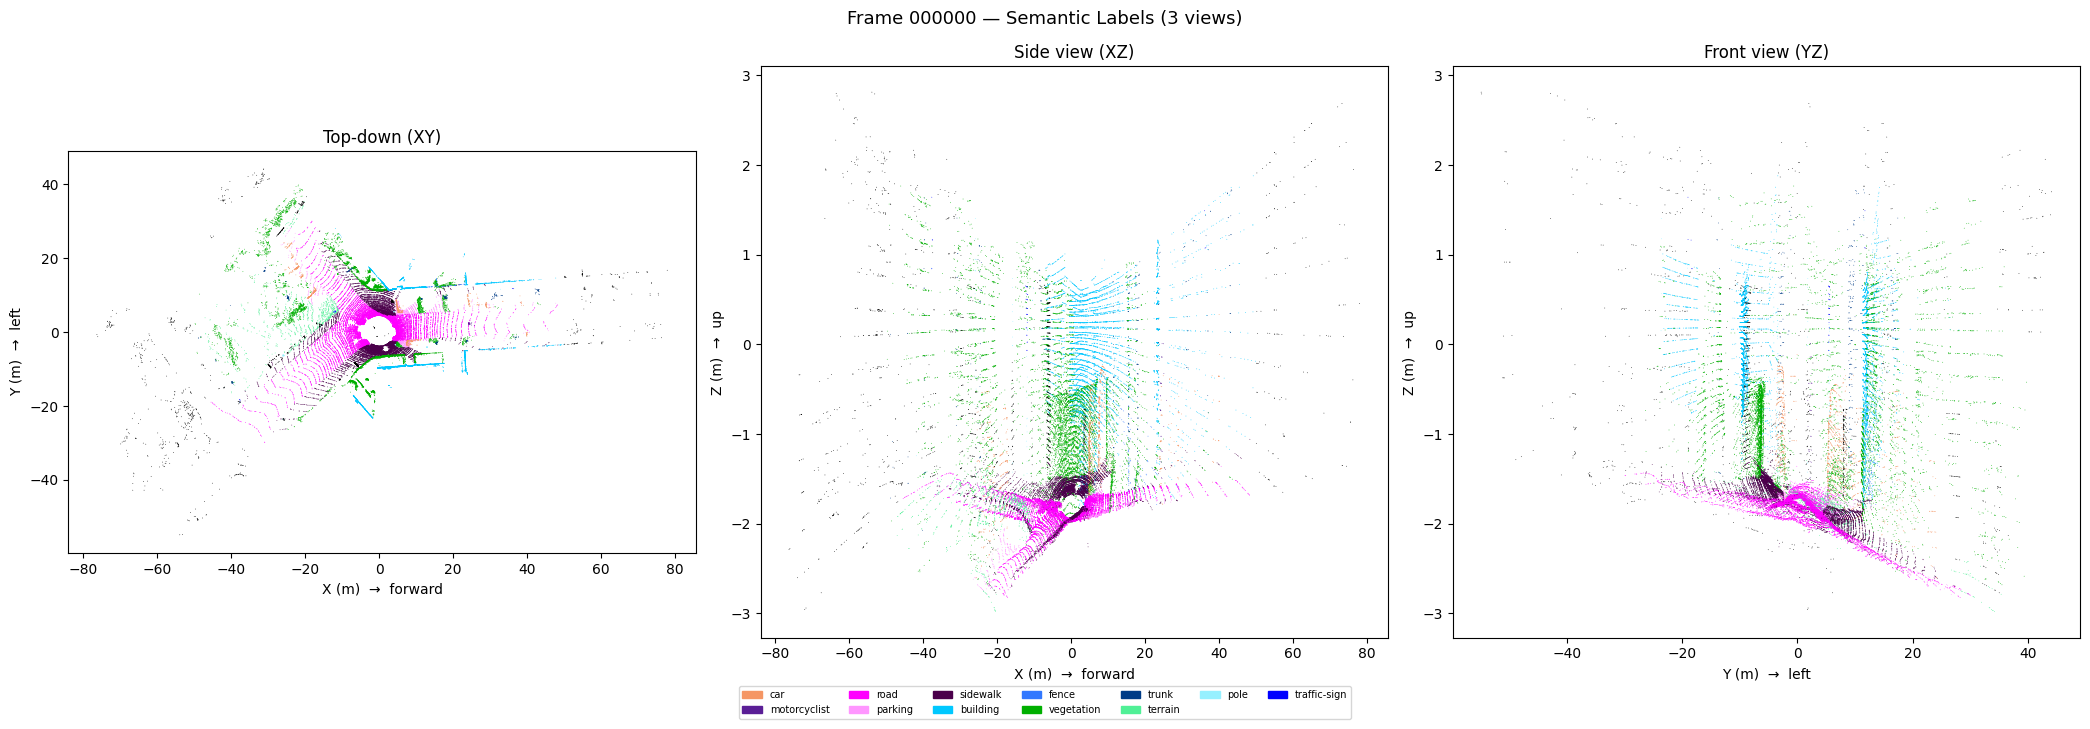

Saved → /content/label_store/000000_views.png


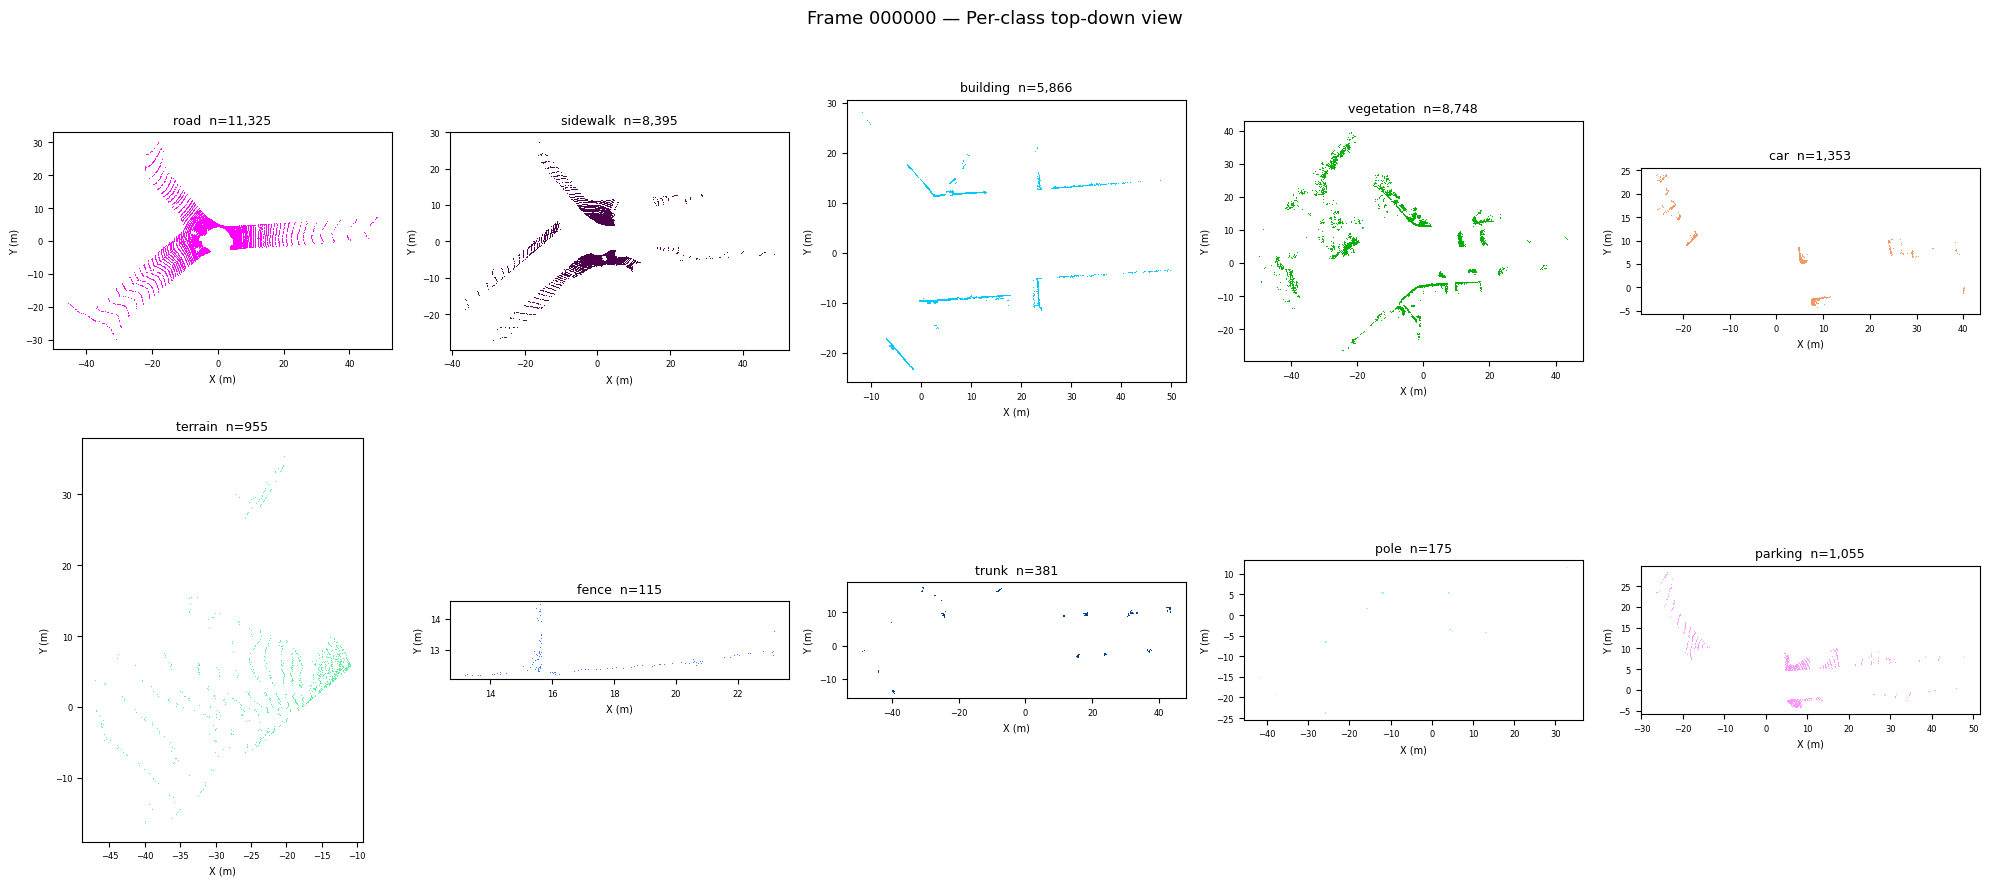

Saved → /content/label_store/000000_per_class.png


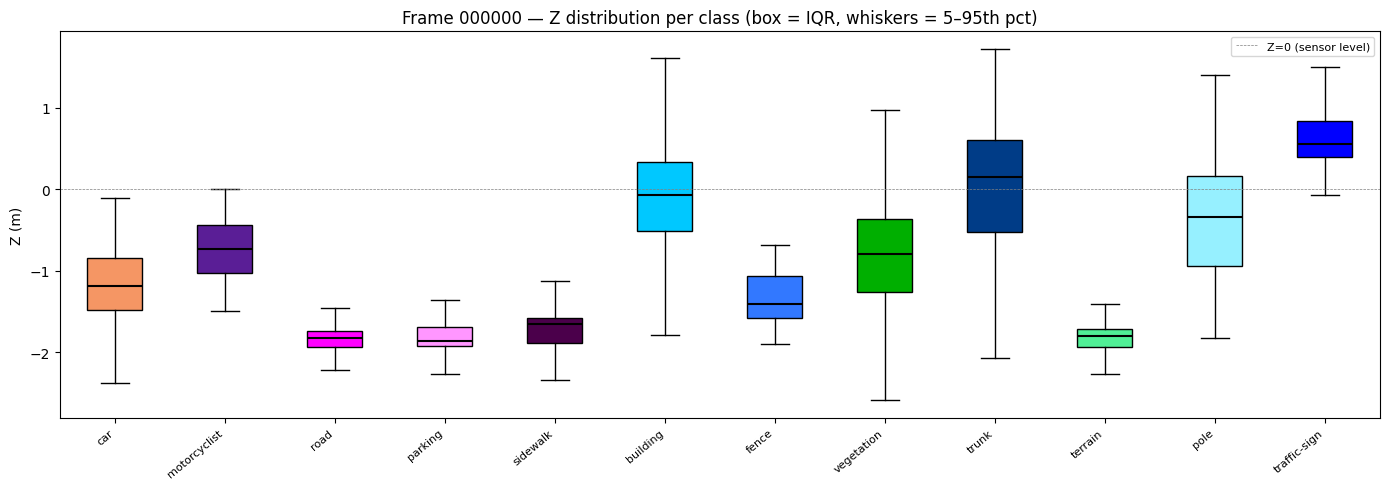

Saved → /content/label_store/000000_z_distribution.png

── Z statistics per class ──
  Class                    n    Z min   Z mean    Z max   Z range
  --------------------------------------------------------------
  unlabeled            4,886   -11.56    -0.41     2.83     14.38
  car                  4,234    -2.61    -1.16     0.33      2.94
  motorcyclist            88    -1.50    -0.75     0.01      1.51
  road                35,281    -2.82    -1.85    -1.43      1.39
  parking              3,268    -2.79    -1.88    -0.94      1.85
  sidewalk            26,360    -2.70    -1.72    -0.98      1.72
  building            18,268    -1.83    -0.11     1.88      3.71
  fence                  370    -1.90    -1.33    -0.69      1.21
  vegetation          27,123    -2.82    -0.70     1.87      4.69
  trunk                1,192    -2.07     0.04     1.72      3.80
  terrain              2,964    -3.00    -1.85    -1.29      1.70
  pole                   532    -1.82    -0.39     1.41   

In [14]:
# -*- coding: utf-8 -*-
"""
visualize_labels.py
───────────────────
Visual label alignment check for frame 000000.

Produces four plots saved to /content/label_store/:

  1. Top-down (XY) — all points coloured by semantic class
  2. Side view (XZ) — height profile coloured by class
  3. Front view (YZ) — lateral slice coloured by class
  4. Per-class point-cloud strips — one row per class, top-down,
     so you can inspect each class in isolation

If the labels are correctly aligned you will see:
  - Road points forming a flat band at the bottom of the scene
  - Buildings forming vertical walls
  - Cars appearing as compact blobs at road level
  - Vegetation distributed above ground level
  - Sidewalks flanking the road
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ── CONFIG ───────────────────────────────────────────────────────
SAMPLE_DIR = "/content/semantic_kitti_sample"
LABEL_DIR  = "/content/semantic_kitti_sample"
OUT_DIR    = "/content/label_store"
FRAME_ID   = "000000"

os.makedirs(OUT_DIR, exist_ok=True)

RAW_TO_LEARNING = {
    0:0, 1:0, 10:1, 11:2, 13:5, 15:3, 16:5, 18:4, 20:5,
    30:6, 31:7, 32:8, 40:9, 44:10, 48:11, 49:12, 50:13,
    51:14, 52:0, 60:9, 70:15, 71:16, 72:17, 80:18, 81:19,
    99:0, 252:1, 253:7, 254:6, 255:8, 256:5, 257:5, 258:4, 259:5,
}
CLASS_NAMES = {
    0:"unlabeled", 1:"car", 2:"bicycle", 3:"motorcycle", 4:"truck",
    5:"other-vehicle", 6:"person", 7:"bicyclist", 8:"motorcyclist",
    9:"road", 10:"parking", 11:"sidewalk", 12:"other-ground",
    13:"building", 14:"fence", 15:"vegetation", 16:"trunk",
    17:"terrain", 18:"pole", 19:"traffic-sign",
}
CLASS_COLORS = np.array([
    [0,   0,   0  ],  #  0 unlabeled
    [245, 150, 100],  #  1 car
    [245, 230, 100],  #  2 bicycle
    [150, 60,  30 ],  #  3 motorcycle
    [180, 30,  80 ],  #  4 truck
    [255, 0,   0  ],  #  5 other-vehicle
    [30,  30,  255],  #  6 person
    [200, 40,  255],  #  7 bicyclist
    [90,  30,  150],  #  8 motorcyclist
    [255, 0,   255],  #  9 road
    [255, 150, 255],  # 10 parking
    [75,  0,   75 ],  # 11 sidewalk
    [75,  0,   175],  # 12 other-ground
    [0,   200, 255],  # 13 building
    [50,  120, 255],  # 14 fence
    [0,   175, 0  ],  # 15 vegetation
    [0,   60,  135],  # 16 trunk
    [80,  240, 150],  # 17 terrain
    [150, 240, 255],  # 18 pole
    [0,   0,   255],  # 19 traffic-sign
], dtype=np.uint8)

# Classes worth showing in the per-class strip plot
# (skip very rare ones that have near-zero points in frame 000000)
CLASSES_TO_SHOW = [9, 11, 13, 15, 1, 17, 14, 16, 18, 10]


def build_lut():
    lut = np.zeros(max(RAW_TO_LEARNING.keys()) + 1, dtype=np.uint8)
    for raw_id, learn_id in RAW_TO_LEARNING.items():
        lut[raw_id] = learn_id
    return lut

LUT = build_lut()


# ── LOAD ─────────────────────────────────────────────────────────
bin_path   = os.path.join(SAMPLE_DIR, f"{FRAME_ID}.bin")
label_path = os.path.join(LABEL_DIR,  f"{FRAME_ID}.label")

pts  = np.fromfile(bin_path,   dtype=np.float32).reshape(-1, 4)
raw  = np.fromfile(label_path, dtype=np.uint32)
sem  = (raw & 0xFFFF).astype(np.int32)
lbls = LUT[np.clip(sem, 0, len(LUT) - 1)]   # (N,) uint8

x, y, z = pts[:, 0], pts[:, 1], pts[:, 2]

# Normalised colours per point
colors = CLASS_COLORS[lbls].astype(np.float32) / 255.0  # (N, 3)

# Downsample for scatter plots (matplotlib struggles with 125k points)
rng      = np.random.default_rng(0)
max_pts  = 40_000
if len(pts) > max_pts:
    idx    = rng.choice(len(pts), size=max_pts, replace=False)
    xs, ys, zs = x[idx], y[idx], z[idx]
    cs         = colors[idx]
    ls         = lbls[idx]
else:
    xs, ys, zs, cs, ls = x, y, z, colors, lbls

print(f"Loaded {len(pts):,} points → plotting {len(xs):,} (downsampled)")


# ── PLOT 1 — three orthographic views ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle(f"Frame {FRAME_ID} — Semantic Labels (3 views)", fontsize=13)

# Top-down XY
ax = axes[0]
ax.scatter(xs, ys, c=cs, s=0.3, linewidths=0)
ax.set_title("Top-down (XY)")
ax.set_xlabel("X (m)  →  forward")
ax.set_ylabel("Y (m)  →  left")
ax.set_aspect("equal")

# Side view XZ  (forward / height)
ax = axes[1]
ax.scatter(xs, zs, c=cs, s=0.3, linewidths=0)
ax.set_title("Side view (XZ)")
ax.set_xlabel("X (m)  →  forward")
ax.set_ylabel("Z (m)  →  up")

# Front view YZ  (lateral / height)
ax = axes[2]
ax.scatter(ys, zs, c=cs, s=0.3, linewidths=0)
ax.set_title("Front view (YZ)")
ax.set_xlabel("Y (m)  →  left")
ax.set_ylabel("Z (m)  →  up")

# Shared legend (classes present in this frame)
present = np.unique(ls)
patches = [
    mpatches.Patch(
        color=CLASS_COLORS[c].astype(np.float32) / 255.0,
        label=CLASS_NAMES.get(c, f"cls{c}")
    )
    for c in present if c != 0
]
fig.legend(handles=patches, loc="lower center", ncol=7,
           fontsize=7, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
p = os.path.join(OUT_DIR, f"{FRAME_ID}_views.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {p}")


# ── PLOT 2 — per-class top-down strips ───────────────────────────
# One row per class; shows only that class's points so you can
# inspect spatial structure without other classes occluding it.
n_show = len(CLASSES_TO_SHOW)
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle(f"Frame {FRAME_ID} — Per-class top-down view", fontsize=13)
axes = axes.ravel()

for i, cls_id in enumerate(CLASSES_TO_SHOW):
    ax   = axes[i]
    mask = ls == cls_id
    name = CLASS_NAMES.get(cls_id, f"cls{cls_id}")
    col  = CLASS_COLORS[cls_id].astype(np.float32) / 255.0

    if mask.sum() == 0:
        ax.set_title(f"{name}\n(no points)")
        ax.axis("off")
        continue

    ax.scatter(xs[mask], ys[mask], c=[col], s=0.5, linewidths=0)
    ax.set_title(f"{name}  n={mask.sum():,}", fontsize=9)
    ax.set_xlabel("X (m)", fontsize=7)
    ax.set_ylabel("Y (m)", fontsize=7)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=6)

plt.tight_layout()
p = os.path.join(OUT_DIR, f"{FRAME_ID}_per_class.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {p}")


# ── PLOT 3 — Z distribution per class (box plot) ─────────────────
# Sanity check: are Z ranges per class physically plausible?
present_cls = [c for c in range(20)
               if c != 0 and (lbls == c).sum() >= 10]

z_data  = [z[lbls == c] for c in present_cls]
z_names = [CLASS_NAMES.get(c, f"cls{c}") for c in present_cls]

fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(z_data, patch_artist=True, showfliers=False,
                medianprops=dict(color="black", linewidth=1.5))

for patch, cls_id in zip(bp["boxes"], present_cls):
    patch.set_facecolor(
        CLASS_COLORS[cls_id].astype(np.float32) / 255.0
    )

ax.set_xticks(range(1, len(z_names) + 1))
ax.set_xticklabels(z_names, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Z (m)")
ax.set_title(f"Frame {FRAME_ID} — Z distribution per class "
             f"(box = IQR, whiskers = 5–95th pct)")
ax.axhline(y=0, color="grey", linewidth=0.5, linestyle="--",
           label="Z=0 (sensor level)")
ax.legend(fontsize=8)
plt.tight_layout()
p = os.path.join(OUT_DIR, f"{FRAME_ID}_z_distribution.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {p}")


# ── QUICK TEXT SUMMARY ───────────────────────────────────────────
print("\n── Z statistics per class ──")
print(f"  {'Class':<18} {'n':>7}  {'Z min':>7}  {'Z mean':>7}  "
      f"{'Z max':>7}  {'Z range':>8}")
print("  " + "-" * 62)
for c in range(20):
    mask = lbls == c
    if mask.sum() < 5:
        continue
    zc = z[mask]
    print(f"  {CLASS_NAMES.get(c,'?'):<18} {mask.sum():>7,}  "
          f"{zc.min():>7.2f}  {zc.mean():>7.2f}  "
          f"{zc.max():>7.2f}  {zc.max()-zc.min():>8.2f}")

print(f"\nAll plots saved to {OUT_DIR}/")
print("Open the images and check:")
print("  views.png    — road=flat band, buildings=vertical, cars=blobs")
print("  per_class.png — each class forms spatially coherent regions")
print("  z_dist.png   — road/terrain Z < sidewalk Z < car Z < building Z")


Processing 000000.bin
Saved voxels → /content/voxel_store/000000_voxels.npz
VOXEL QUALITY REPORT

── Overall ──
  Total voxels      : 62,158
  Total points      : 124,668
  Compression ratio : 2.01 pts/voxel

── Points per voxel ──
  Min    : 1
  Max    : 18
  Mean   : 2.01
  Median : 2.0
  1-pt voxels  : 28,371 (45.6%)
  >10pt voxels : 94 (0.2%)

── Height range per voxel ──
  Min  : 0.0000 m
  Max  : 0.4880 m
  Mean : 0.0100 m
  Suspicious (>2m) : 0
  Flat (=0m)       : 28,382

── Per-level breakdown ──

  L0 (5cm) — 33,922 voxels
    pts/voxel : min=1 mean=1.84 max=8
    height_range : min=0.000 mean=0.002 max=0.049
    single-pt : 15,575 (45.9%)

  L1 (15cm) — 23,934 voxels
    pts/voxel : min=1 mean=2.21 max=18
    height_range : min=0.000 mean=0.014 max=0.148
    single-pt : 10,752 (44.9%)

  L2 (50cm) — 4,302 voxels
    pts/voxel : min=1 mean=2.18 max=15
    height_range : min=0.000 mean=0.055 max=0.488
    single-pt : 2,044 (47.5%)

── Spatial coverage ──
  X : -78.2 to 77.8 m

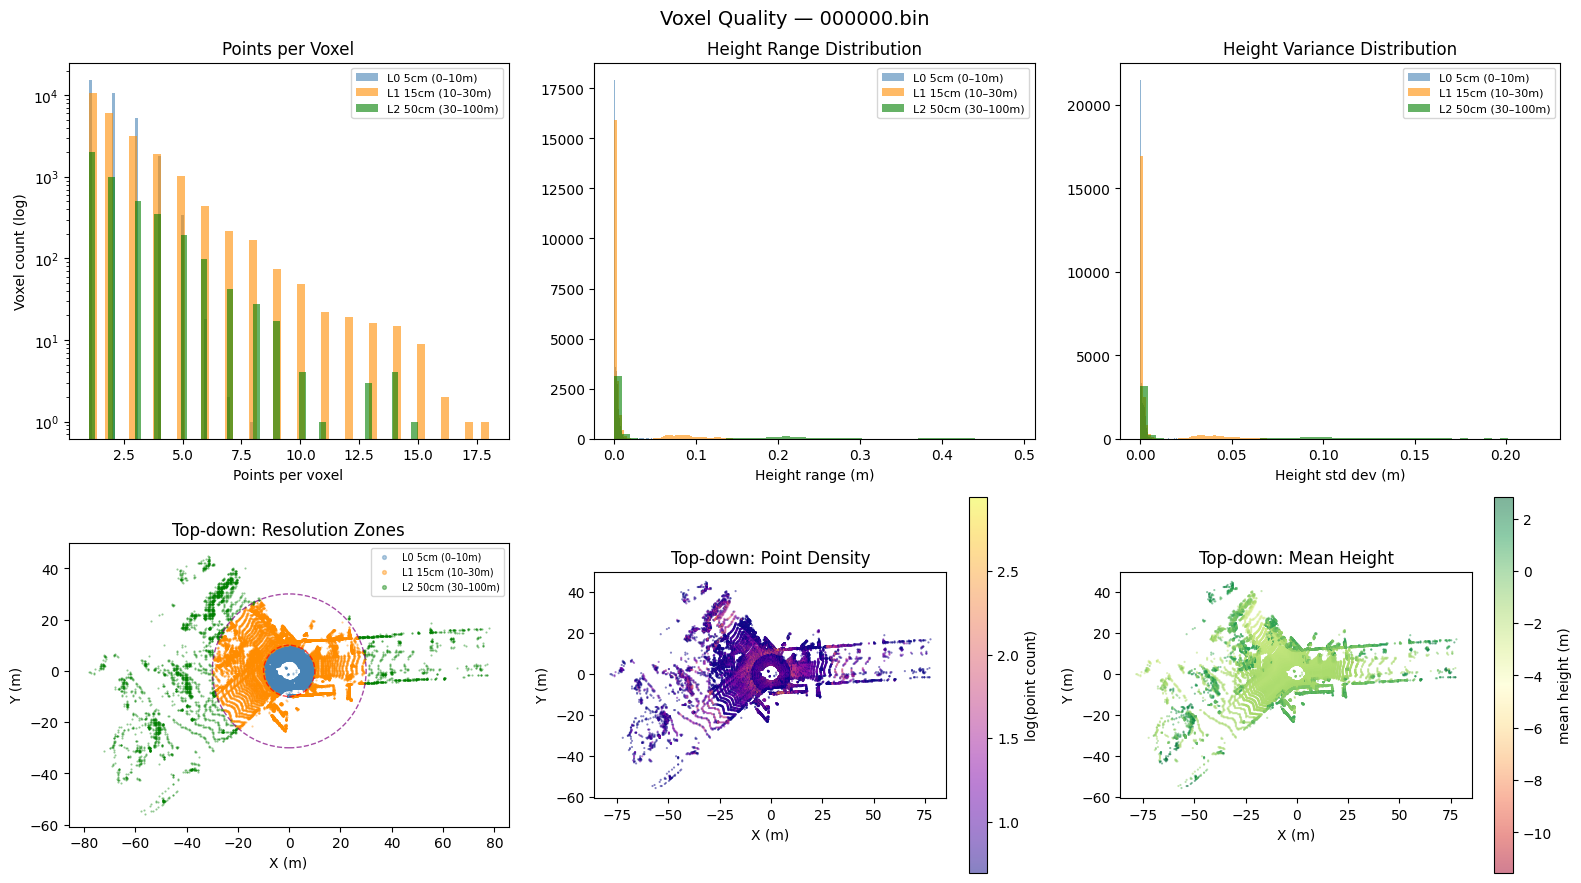

Saved: /content/voxel_store/000000_quality.png

── Storage verification: 000000 ──
  ✓ voxel count
  ✓ height_mean match
  ✓ height_min match
  ✓ point_count match
  ✓ levels match
  File size : 1326.4 KB

Processing 000001.bin
Saved voxels → /content/voxel_store/000001_voxels.npz
VOXEL QUALITY REPORT

── Overall ──
  Total voxels      : 62,256
  Total points      : 124,605
  Compression ratio : 2.00 pts/voxel

── Points per voxel ──
  Min    : 1
  Max    : 18
  Mean   : 2.00
  Median : 2.0
  1-pt voxels  : 28,352 (45.5%)
  >10pt voxels : 71 (0.1%)

── Height range per voxel ──
  Min  : 0.0000 m
  Max  : 0.4870 m
  Mean : 0.0099 m
  Suspicious (>2m) : 0
  Flat (=0m)       : 28,367

── Per-level breakdown ──

  L0 (5cm) — 34,389 voxels
    pts/voxel : min=1 mean=1.84 max=8
    height_range : min=0.000 mean=0.002 max=0.049
    single-pt : 15,770 (45.9%)

  L1 (15cm) — 23,592 voxels
    pts/voxel : min=1 mean=2.21 max=17
    height_range : min=0.000 mean=0.014 max=0.148
    single-pt : 10

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# import json
# import time
# from collections import Counter

# # ─────────────────────────────────────────
# # CONFIG
# # ─────────────────────────────────────────
# BANDS = [
#     (0,  10,  0.05, 0),
#     (10, 30,  0.15, 1),
#     (30, 100, 0.50, 2),
# ]

# SIZE_MAP = np.array([0.05, 0.15, 0.50], dtype=np.float32)

# FILES = [
#     f"/content/semantic_kitti_sample/{i:06d}.bin"
#     for i in range(10)
# ]

# SAVE_DIR = "/content/voxel_store"
# os.makedirs(SAVE_DIR, exist_ok=True)

# # ─────────────────────────────────────────
# # PIPELINE
# # ─────────────────────────────────────────
# def load_points(path):
#     return np.fromfile(path, dtype=np.float32).reshape(-1, 4)


# class VoxelPipeline:
#     def __init__(self, max_points=150000, max_voxels=100000):
#         self.max_points = max_points
#         self.max_voxels = max_voxels
#         self.levels   = np.zeros(max_points, dtype=np.int32)
#         self.vox_size = np.zeros(max_points, dtype=np.float32)
#         self.dist     = np.zeros(max_points, dtype=np.float32)
#         self.count    = np.zeros(max_voxels, dtype=np.int32)
#         self.z_sum    = np.zeros(max_voxels, dtype=np.float64)
#         self.z_sum2   = np.zeros(max_voxels, dtype=np.float64)
#         self.z_min    = np.zeros(max_voxels, dtype=np.float64)
#         self.z_max    = np.zeros(max_voxels, dtype=np.float64)
#         self.i_sum    = np.zeros(max_voxels, dtype=np.float64)

#     def process(self, points):
#         N = len(points)

#         # ── assign levels ──────────────────────────────
#         dist     = self.dist[:N]
#         levels   = self.levels[:N]
#         vox_size = self.vox_size[:N]

#         np.sqrt(points[:,0]**2 + points[:,1]**2, out=dist)

#         levels[:]   = 2;  vox_size[:] = 0.50
#         m1 = dist < 30;   levels[m1]  = 1; vox_size[m1] = 0.15
#         m0 = dist < 10;   levels[m0]  = 0; vox_size[m0] = 0.05

#         # ── hash grid ──────────────────────────────────
#         coords = np.floor(
#             points[:,:3] / vox_size[:,None]
#         ).astype(np.int32)

#         keys   = np.stack([levels,
#                            coords[:,0],
#                            coords[:,1],
#                            coords[:,2]], axis=1).astype(np.int32)
#         keys_c = np.ascontiguousarray(keys)
#         keys_v = keys_c.view(
#             np.dtype((np.void, keys_c.dtype.itemsize * 4))
#         ).ravel()

#         unique_void, inverse = np.unique(keys_v, return_inverse=True)
#         unique_keys = unique_void.view(np.int32).reshape(-1, 4)

#         sort_order     = np.argsort(inverse, kind='stable')
#         sorted_inverse = inverse[sort_order]
#         split_points   = np.searchsorted(
#             sorted_inverse, np.arange(len(unique_keys))
#         )

#         # ── features ───────────────────────────────────
#         V     = len(unique_keys)
#         z     = points[:,2].astype(np.float64)
#         inten = points[:,3].astype(np.float64)

#         count  = self.count[:V];  count[:]  = 0
#         z_sum  = self.z_sum[:V];  z_sum[:]  = 0
#         z_sum2 = self.z_sum2[:V]; z_sum2[:] = 0
#         z_min  = self.z_min[:V];  z_min[:]  =  np.inf
#         z_max  = self.z_max[:V];  z_max[:]  = -np.inf
#         i_sum  = self.i_sum[:V];  i_sum[:]  = 0

#         np.add.at(count,  inverse, 1)
#         np.add.at(z_sum,  inverse, z)
#         np.add.at(z_sum2, inverse, z**2)
#         np.minimum.at(z_min, inverse, z)
#         np.maximum.at(z_max, inverse, z)
#         np.add.at(i_sum,  inverse, inten)

#         z_mean  = z_sum  / count
#         z_var   = z_sum2 / count - z_mean**2
#         z_range = z_max  - z_min
#         i_mean  = i_sum  / count

#         lv = unique_keys[:,0]
#         vs = SIZE_MAP[lv]
#         cx = (unique_keys[:,1] + 0.5) * vs
#         cy = (unique_keys[:,2] + 0.5) * vs
#         cz = (unique_keys[:,3] + 0.5) * vs

#         return {
#             "unique_keys":    unique_keys,
#             "levels":         lv,
#             "vox_size":       vs,
#             "center_x":       cx,
#             "center_y":       cy,
#             "center_z":       cz,
#             "point_count":    count.copy(),
#             "height_mean":    z_mean.copy(),
#             "height_min":     z_min.copy(),
#             "height_max":     z_max.copy(),
#             "height_var":     z_var.copy(),
#             "height_range":   z_range.copy(),
#             "intensity_mean": i_mean.copy(),
#         }


# # ─────────────────────────────────────────
# # STORAGE
# # ─────────────────────────────────────────
# def save_voxels(features, frame_name, save_dir):
#     """
#     Save all voxel arrays as a single compressed .npz file.
#     One file per frame. Loads back instantly with np.load.

#     Stored arrays:
#       keys        — (V,4) int32  [level, ix, iy, iz]
#       levels      — (V,)  int32
#       vox_size    — (V,)  float32
#       center_xyz  — (V,3) float32  [cx, cy, cz]
#       point_count — (V,)  int32
#       height_mean — (V,)  float32
#       height_min  — (V,)  float32
#       height_max  — (V,)  float32
#       height_var  — (V,)  float32
#       height_range— (V,)  float32
#       intensity   — (V,)  float32
#     """
#     frame_id = os.path.splitext(frame_name)[0]
#     out_path = os.path.join(save_dir, f"{frame_id}_voxels.npz")

#     center_xyz = np.stack([
#         features["center_x"],
#         features["center_y"],
#         features["center_z"]
#     ], axis=1).astype(np.float32)

#     np.savez_compressed(
#         out_path,
#         keys         = features["unique_keys"].astype(np.int32),
#         levels       = features["levels"].astype(np.int32),
#         vox_size     = features["vox_size"].astype(np.float32),
#         center_xyz   = center_xyz,
#         point_count  = features["point_count"].astype(np.int32),
#         height_mean  = features["height_mean"].astype(np.float32),
#         height_min   = features["height_min"].astype(np.float32),
#         height_max   = features["height_max"].astype(np.float32),
#         height_var   = features["height_var"].astype(np.float32),
#         height_range = features["height_range"].astype(np.float32),
#         intensity    = features["intensity_mean"].astype(np.float32),
#     )
#     return out_path


# def load_voxels(frame_id, save_dir):
#     """
#     Load a saved voxel frame back into a features dict.
#     Usage: features = load_voxels("000000", SAVE_DIR)
#     """
#     path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
#     d    = np.load(path)
#     return {
#         "unique_keys":    d["keys"],
#         "levels":         d["levels"],
#         "vox_size":       d["vox_size"],
#         "center_x":       d["center_xyz"][:,0],
#         "center_y":       d["center_xyz"][:,1],
#         "center_z":       d["center_xyz"][:,2],
#         "point_count":    d["point_count"],
#         "height_mean":    d["height_mean"],
#         "height_min":     d["height_min"],
#         "height_max":     d["height_max"],
#         "height_var":     d["height_var"],
#         "height_range":   d["height_range"],
#         "intensity_mean": d["intensity"],
#     }


# def save_metadata(results, save_dir):
#     """
#     Save per-frame summary stats as JSON.
#     Useful for the benchmark table later.
#     """
#     meta_path = os.path.join(save_dir, "metadata.json")
#     with open(meta_path, "w") as f:
#         json.dump(results, f, indent=2)
#     return meta_path


# # ─────────────────────────────────────────
# # QUALITY REPORT
# # ─────────────────────────────────────────
# def voxel_quality_report(features, points):
#     pcount = features["point_count"]
#     hrange = features["height_range"]
#     hvar   = features["height_var"]
#     levels = features["levels"]

#     print("=" * 60)
#     print("VOXEL QUALITY REPORT")
#     print("=" * 60)

#     # ── overall ────────────────────────────────────────
#     print(f"\n── Overall ──")
#     print(f"  Total voxels      : {len(pcount):,}")
#     print(f"  Total points      : {len(points):,}")
#     print(f"  Compression ratio : {len(points)/len(pcount):.2f} pts/voxel")

#     # ── points per voxel ───────────────────────────────
#     print(f"\n── Points per voxel ──")
#     print(f"  Min    : {pcount.min()}")
#     print(f"  Max    : {pcount.max()}")
#     print(f"  Mean   : {pcount.mean():.2f}")
#     print(f"  Median : {np.median(pcount):.1f}")
#     print(f"  1-pt voxels  : {(pcount==1).sum():,} "
#           f"({(pcount==1).mean()*100:.1f}%)")
#     print(f"  >10pt voxels : {(pcount>10).sum():,} "
#           f"({(pcount>10).mean()*100:.1f}%)")

#     # ── height range ───────────────────────────────────
#     print(f"\n── Height range per voxel ──")
#     print(f"  Min  : {hrange.min():.4f} m")
#     print(f"  Max  : {hrange.max():.4f} m")
#     print(f"  Mean : {hrange.mean():.4f} m")
#     print(f"  Suspicious (>2m) : {(hrange>2).sum():,}")
#     print(f"  Flat (=0m)       : {(hrange==0).sum():,}")

#     # ── per level ──────────────────────────────────────
#     print(f"\n── Per-level breakdown ──")
#     size_labels = {0: "5cm", 1: "15cm", 2: "50cm"}
#     for lv in [0, 1, 2]:
#         mask = levels == lv
#         if mask.sum() == 0:
#             continue
#         pc = pcount[mask]
#         hr = hrange[mask]
#         print(f"\n  L{lv} ({size_labels[lv]}) — {mask.sum():,} voxels")
#         print(f"    pts/voxel : "
#               f"min={pc.min()} "
#               f"mean={pc.mean():.2f} "
#               f"max={pc.max()}")
#         print(f"    height_range : "
#               f"min={hr.min():.3f} "
#               f"mean={hr.mean():.3f} "
#               f"max={hr.max():.3f}")
#         print(f"    single-pt : {(pc==1).sum():,} "
#               f"({(pc==1).mean()*100:.1f}%)")

#     # ── spatial coverage ───────────────────────────────
#     print(f"\n── Spatial coverage ──")
#     print(f"  X : {features['center_x'].min():.1f} "
#           f"to {features['center_x'].max():.1f} m")
#     print(f"  Y : {features['center_y'].min():.1f} "
#           f"to {features['center_y'].max():.1f} m")
#     print(f"  Z : {features['center_z'].min():.1f} "
#           f"to {features['center_z'].max():.1f} m")


# def check_zone_boundaries(features):
#     print(f"\n── Zone boundary check ──")
#     cx   = features["center_x"]
#     cy   = features["center_y"]
#     lv   = features["levels"]
#     dist = np.sqrt(cx**2 + cy**2)

#     for boundary, lo, hi, lv_a, lv_b in [
#         (10, 8,  12, 0, 1),
#         (30, 28, 32, 1, 2),
#     ]:
#         zone = (dist > lo) & (dist < hi)
#         if zone.sum() == 0:
#             continue
#         la = (lv[zone] == lv_a).sum()
#         lb = (lv[zone] == lv_b).sum()
#         print(f"\n  {lo}–{hi}m (around {boundary}m boundary)")
#         print(f"    L{lv_a} voxels : {la}")
#         print(f"    L{lv_b} voxels : {lb}")

#     # Use tolerance of half a 50cm voxel = 0.25m
#     TOLERANCE = 0.25
#     l0_far  = ((lv == 0) & (dist > 10 + TOLERANCE)).sum()
#     l2_near = ((lv == 2) & (dist < 30 - TOLERANCE)).sum()

#     print(f"\n  L0 voxels beyond {10+TOLERANCE}m : {l0_far} "
#           f"{'✓' if l0_far==0 else '✗ WARNING'}")
#     print(f"  L2 voxels within {30-TOLERANCE}m : {l2_near} "
#           f"{'✓' if l2_near==0 else '✗ WARNING'}")
#     print(f"  (tolerance = {TOLERANCE}m = half one L2 voxel width)")

# # ─────────────────────────────────────────
# # QUALITY PLOTS
# # ─────────────────────────────────────────
# def voxel_quality_plots(features, frame_name, save_dir):
#     pcount = features["point_count"]
#     hrange = features["height_range"]
#     hvar   = features["height_var"]
#     levels = features["levels"]
#     cx     = features["center_x"]
#     cy     = features["center_y"]

#     colors = ['steelblue', 'darkorange', 'green']
#     labels = ['L0 5cm (0–10m)',
#               'L1 15cm (10–30m)',
#               'L2 50cm (30–100m)']

#     fig, axes = plt.subplots(2, 3, figsize=(16, 9))
#     fig.suptitle(f"Voxel Quality — {frame_name}", fontsize=14)

#     # ── 1: points per voxel ────────────────────────────
#     ax = axes[0, 0]
#     for lv in [0, 1, 2]:
#         mask = levels == lv
#         ax.hist(pcount[mask], bins=50, alpha=0.6,
#                 color=colors[lv], label=labels[lv])
#     ax.set_xlabel("Points per voxel")
#     ax.set_ylabel("Voxel count (log)")
#     ax.set_title("Points per Voxel")
#     ax.legend(fontsize=8)
#     ax.set_yscale('log')

#     # ── 2: height range ────────────────────────────────
#     ax = axes[0, 1]
#     for lv in [0, 1, 2]:
#         mask = levels == lv
#         ax.hist(hrange[mask], bins=50, alpha=0.6,
#                 color=colors[lv], label=labels[lv])
#     ax.set_xlabel("Height range (m)")
#     ax.set_title("Height Range Distribution")
#     ax.legend(fontsize=8)

#     # ── 3: height std dev ──────────────────────────────
#     ax = axes[0, 2]
#     for lv in [0, 1, 2]:
#         mask = levels == lv
#         ax.hist(np.sqrt(hvar[mask] + 1e-9),
#                 bins=50, alpha=0.6,
#                 color=colors[lv], label=labels[lv])
#     ax.set_xlabel("Height std dev (m)")
#     ax.set_title("Height Variance Distribution")
#     ax.legend(fontsize=8)

#     # ── 4: top-down by level ───────────────────────────
#     ax = axes[1, 0]
#     for lv in [0, 1, 2]:
#         mask = levels == lv
#         ax.scatter(cx[mask], cy[mask],
#                    s=0.3, alpha=0.4,
#                    color=colors[lv], label=labels[lv])
#     # Draw boundary rings
#     for r, c in [(10,'red'), (30,'purple')]:
#         circle = plt.Circle((0,0), r, color=c,
#                              fill=False, linewidth=1,
#                              linestyle='--', alpha=0.7)
#         ax.add_patch(circle)
#     ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
#     ax.set_title("Top-down: Resolution Zones")
#     ax.legend(fontsize=7, markerscale=5)
#     ax.set_aspect('equal')

#     # ── 5: point density ───────────────────────────────
#     ax = axes[1, 1]
#     sc = ax.scatter(cx, cy,
#                     c=np.log1p(pcount),
#                     s=0.3, alpha=0.5, cmap='plasma')
#     plt.colorbar(sc, ax=ax, label='log(point count)')
#     ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
#     ax.set_title("Top-down: Point Density")
#     ax.set_aspect('equal')

#     # ── 6: mean height ─────────────────────────────────
#     ax = axes[1, 2]
#     sc = ax.scatter(cx, cy,
#                     c=features["height_mean"],
#                     s=0.3, alpha=0.5, cmap='RdYlGn')
#     plt.colorbar(sc, ax=ax, label='mean height (m)')
#     ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
#     ax.set_title("Top-down: Mean Height")
#     ax.set_aspect('equal')

#     plt.tight_layout()
#     plot_path = os.path.join(
#         save_dir,
#         f"{os.path.splitext(frame_name)[0]}_quality.png"
#     )
#     plt.savefig(plot_path, dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"Saved: {plot_path}")


# # ─────────────────────────────────────────
# # STORAGE VERIFICATION
# # ─────────────────────────────────────────
# def verify_storage(frame_id, save_dir, original_features):
#     """
#     Load saved voxels back and confirm they match original.
#     """
#     print(f"\n── Storage verification: {frame_id} ──")
#     loaded = load_voxels(frame_id, save_dir)

#     checks = [
#         ("voxel count",
#          len(loaded["unique_keys"]) == len(original_features["unique_keys"])),
#         ("height_mean match",
#          np.allclose(loaded["height_mean"],
#                      original_features["height_mean"].astype(np.float32),
#                      atol=1e-4)),
#         ("height_min match",
#          np.allclose(loaded["height_min"],
#                      original_features["height_min"].astype(np.float32),
#                      atol=1e-4)),
#         ("point_count match",
#          np.array_equal(loaded["point_count"],
#                         original_features["point_count"])),
#         ("levels match",
#          np.array_equal(loaded["levels"],
#                         original_features["levels"])),
#     ]

#     all_ok = True
#     for name, result in checks:
#         status = "✓" if result else "✗"
#         print(f"  {status} {name}")
#         if not result:
#             all_ok = False

#     # File size
#     npz_path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
#     size_kb  = os.path.getsize(npz_path) / 1024
#     print(f"  File size : {size_kb:.1f} KB")
#     return all_ok


# # ─────────────────────────────────────────
# # MAIN
# # ─────────────────────────────────────────
# pipeline = VoxelPipeline(max_points=150000, max_voxels=100000)
# _ = pipeline.process(load_points(FILES[0]))  # warmup

# all_meta = []

# for fpath in FILES:
#     fname  = os.path.basename(fpath)
#     fid    = os.path.splitext(fname)[0]

#     print(f"\n{'='*60}")
#     print(f"Processing {fname}")
#     print(f"{'='*60}")

#     # ── run pipeline ───────────────────────────────────
#     points   = load_points(fpath)
#     t0       = time.perf_counter()
#     features = pipeline.process(points)
#     elapsed  = (time.perf_counter() - t0) * 1000

#     # ── save voxels ────────────────────────────────────
#     out_path = save_voxels(features, fname, SAVE_DIR)
#     print(f"Saved voxels → {out_path}")

#     # ── quality report ─────────────────────────────────
#     voxel_quality_report(features, points)
#     check_zone_boundaries(features)

#     # ── plots (first frame only to avoid too many images)
#     if fid == "000000":
#         voxel_quality_plots(features, fname, SAVE_DIR)

#     # ── verify storage ─────────────────────────────────
#     verify_storage(fid, SAVE_DIR, features)

#     # ── collect metadata ───────────────────────────────
#     pcount = features["point_count"]
#     all_meta.append({
#         "frame":         fid,
#         "n_points":      int(len(points)),
#         "n_voxels":      int(len(features["unique_keys"])),
#         "n_l0":          int((features["levels"]==0).sum()),
#         "n_l1":          int((features["levels"]==1).sum()),
#         "n_l2":          int((features["levels"]==2).sum()),
#         "pts_per_voxel": float(pcount.mean()),
#         "height_range_mean": float(features["height_range"].mean()),
#         "pipeline_ms":   float(elapsed),
#         "fps":           float(1000/elapsed),
#         "npz_size_kb":   float(
#             os.path.getsize(
#                 os.path.join(SAVE_DIR, f"{fid}_voxels.npz")
#             ) / 1024
#         ),
#     })

# # ── save metadata ──────────────────────────────────────
# meta_path = save_metadata(all_meta, SAVE_DIR)
# print(f"\nMetadata saved → {meta_path}")

# # ── final storage summary ──────────────────────────────
# print("\n" + "="*70)
# print("STORAGE SUMMARY")
# print("="*70)
# print(f"{'Frame':<12} {'Voxels':>8} {'pts/vox':>8} "
#       f"{'FPS':>6} {'File KB':>8}")
# print("-"*70)
# for m in all_meta:
#     print(f"{m['frame']:<12} {m['n_voxels']:>8,} "
#           f"{m['pts_per_voxel']:>8.2f} "
#           f"{m['fps']:>6.1f} "
#           f"{m['npz_size_kb']:>8.1f}")

# total_kb = sum(m['npz_size_kb'] for m in all_meta)
# print(f"\n  Total storage (10 frames) : {total_kb:.1f} KB "
#       f"= {total_kb/1024:.2f} MB")
# print(f"  Avg per frame             : {total_kb/len(all_meta):.1f} KB")
# print(f"\nFiles saved to: {SAVE_DIR}")
# print("\nTo reload any frame later:")
# print('  features = load_voxels("000000", SAVE_DIR)')

Frame             L0 grid      L1 grid      L2 grid    Proj ms    FPS
--------------------------------------------------------------------------------
000000.bin   397×   399 398×   342 313×   202      35.4ms  28.3
000001.bin   399×   400 399×   332 319×   213      68.0ms  14.7
000002.bin   400×   400 400×   324 317×   196      46.2ms  21.6
000003.bin   399×   400 398×   317 318×   181      82.6ms  12.1
000004.bin   398×   396 398×   309 317×   176      78.1ms  12.8
000005.bin   396×   396 398×   302 313×   172      40.9ms  24.5
000006.bin   391×   393 399×   296 313×   171      38.9ms  25.7
000007.bin   395×   389 399×   286 317×   170      39.3ms  25.5
000008.bin   400×   388 400×   279 316×   169      39.0ms  25.6
000009.bin   398×   390 400×   274 315×   169      52.8ms  18.9

Running quality report and visualization on 000000...

── 2.5D Map Quality Report ──

  L0_5cm
    Grid size     : 397 × 399 = 158,403 cells
    Occupied      : 25,455 (16.1%)
    X range       : -10.0 – 9.9 

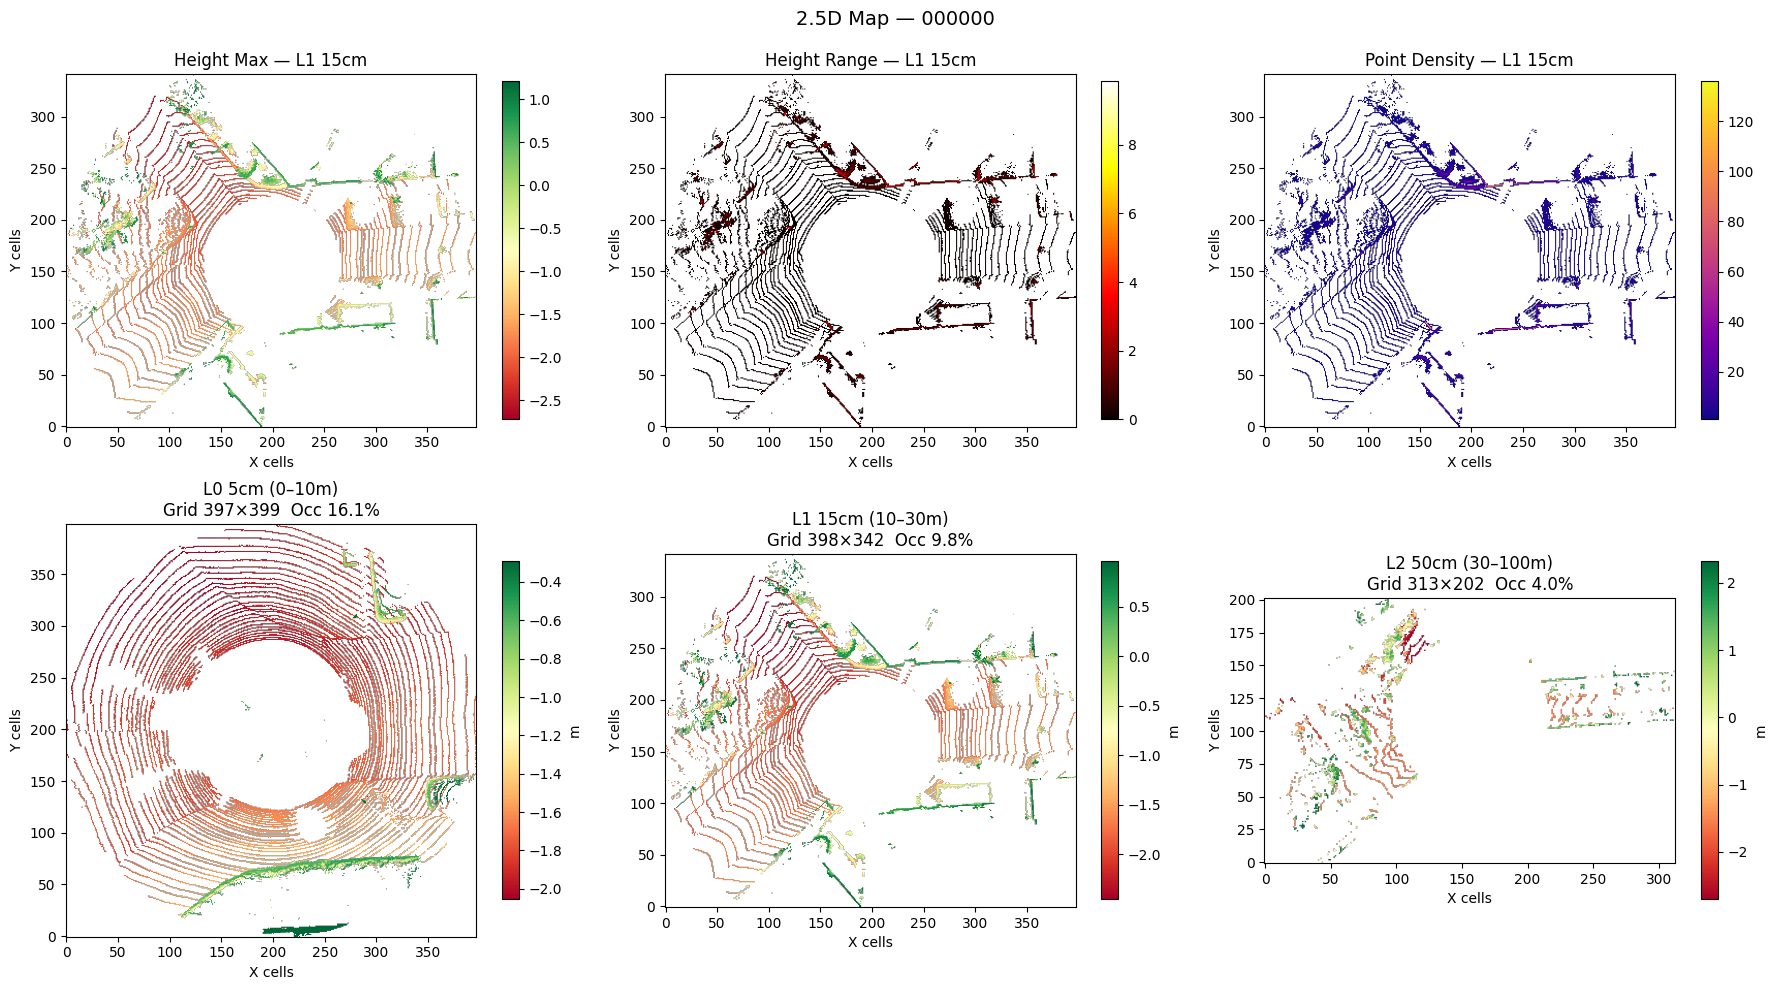

  Saved plot → /content/maps_2d/000000_map2d.png


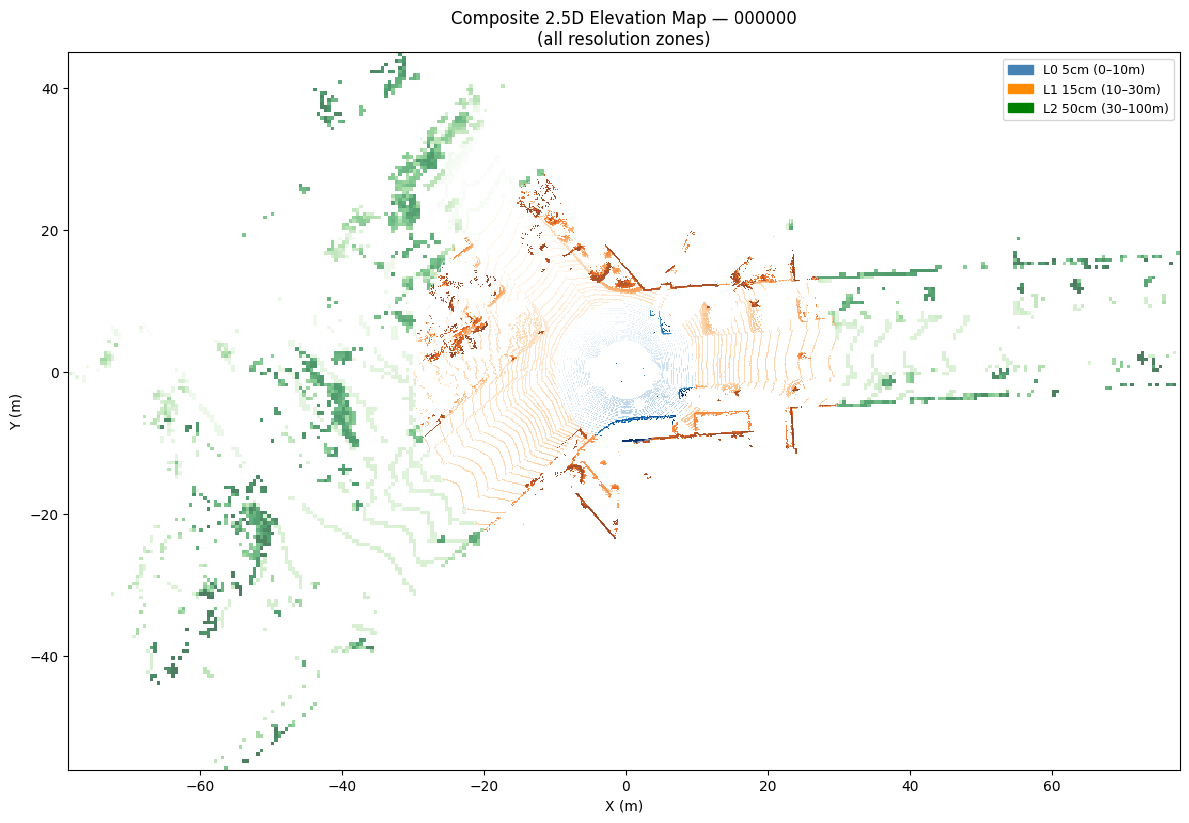

  Saved composite → /content/maps_2d/000000_composite.png

SUMMARY
  Avg projection time : 52.1 ms
  Avg FPS             : 21.0
  Min FPS             : 12.1
  Max FPS             : 28.3

  Avg L0 occupancy    : 15.8%
  Avg L1 occupancy    : 10.0%
  Avg L2 occupancy    : 4.2%

  Voxelization FPS    : ~13.0
  Projection FPS      : 21.0
  Combined estimate   : 7.8 FPS

  Map storage (10 frames) : 7371.0 KB = 7.20 MB
  Avg per frame           : 737.1 KB

Maps saved to: /content/maps_2d


In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import os
# import time

# # ─────────────────────────────────────────
# # CONFIG
# # ─────────────────────────────────────────
# SAVE_DIR   = "/content/voxel_store"
# MAP_DIR    = "/content/maps_2d"
# os.makedirs(MAP_DIR, exist_ok=True)

# SIZE_MAP   = np.array([0.05, 0.15, 0.50], dtype=np.float32)
# LEVEL_NAMES = {0: "L0_5cm", 1: "L1_15cm", 2: "L2_50cm"}

# # Feature channel indices inside the grid array
# CH = {
#     "height_max":    0,
#     "height_min":    1,
#     "height_range":  2,
#     "height_mean":   3,
#     "point_count":   4,
#     "voxel_count":   5,
#     "intensity":     6,
#     "is_occupied":   7,
#     "pts_per_m2":    8,
# }
# N_CHANNELS = len(CH)

# FILES = [
#     f"/kaggle/input/datasets/hbenallal/semantickitti/dataset/sequences/00/velodyne/{i:06d}.bin"
#     for i in range(10)
# ]

# # ─────────────────────────────────────────
# # LOAD SAVED VOXELS
# # ─────────────────────────────────────────
# def load_voxels(frame_id, save_dir):
#     path = os.path.join(save_dir, f"{frame_id}_voxels.npz")
#     d    = np.load(path)
#     return {
#         "unique_keys":    d["keys"],
#         "levels":         d["levels"],
#         "vox_size":       d["vox_size"],
#         "center_x":       d["center_xyz"][:,0],
#         "center_y":       d["center_xyz"][:,1],
#         "center_z":       d["center_xyz"][:,2],
#         "point_count":    d["point_count"],
#         "height_mean":    d["height_mean"],
#         "height_min":     d["height_min"],
#         "height_max":     d["height_max"],
#         "height_var":     d["height_var"],
#         "height_range":   d["height_range"],
#         "intensity_mean": d["intensity"],
#     }


# # ─────────────────────────────────────────
# # GRID DIMENSIONS
# # ─────────────────────────────────────────
# def compute_grid_bounds(features, level):
#     """
#     Compute grid size for one level based on actual
#     voxel center positions. Returns (grid, ix, iy, offset_x, offset_y).
#     """
#     mask = features["levels"] == level
#     if mask.sum() == 0:
#         return None, None, None, None, None

#     vs  = SIZE_MAP[level]
#     cx  = features["center_x"][mask]
#     cy  = features["center_y"][mask]

#     # Voxel indices in 2D (drop Z)
#     ix  = np.floor(cx / vs).astype(np.int32)
#     iy  = np.floor(cy / vs).astype(np.int32)

#     # Shift to zero-based indices
#     ix_min = ix.min()
#     iy_min = iy.min()
#     ix_rel = ix - ix_min
#     iy_rel = iy - iy_min

#     H = ix_rel.max() + 1   # rows = X axis
#     W = iy_rel.max() + 1   # cols = Y axis

#     return H, W, ix_rel, iy_rel, ix_min, iy_min, mask


# # ─────────────────────────────────────────
# # CORE PROJECTION — fully vectorized
# # ─────────────────────────────────────────
# def project_level(features, level):
#     """
#     Project all voxels of one level into a 2D grid.
#     Returns grid of shape (H, W, N_CHANNELS).

#     Aggregation per cell:
#       height_max   → max of voxel height_max
#       height_min   → min of voxel height_min
#       height_range → cell height_max - cell height_min  (recomputed)
#       height_mean  → point-weighted mean
#       point_count  → sum
#       voxel_count  → count of contributing voxels
#       intensity    → point-weighted mean
#       is_occupied  → 1 if any voxel contributes
#       pts_per_m2   → point_count / cell_area
#     """
#     result = compute_grid_bounds(features, level)
#     if result[0] is None:
#         return None, None

#     H, W, ix_rel, iy_rel, ix_min, iy_min, mask = result
#     vs       = SIZE_MAP[level]
#     cell_area = float(vs) ** 2

#     # Extract masked arrays
#     h_max  = features["height_max"][mask].astype(np.float32)
#     h_min  = features["height_min"][mask].astype(np.float32)
#     h_mean = features["height_mean"][mask].astype(np.float32)
#     pcount = features["point_count"][mask].astype(np.float32)
#     inten  = features["intensity_mean"][mask].astype(np.float32)

#     # Flat cell indices for vectorized scatter
#     flat = ix_rel * W + iy_rel
#     C    = H * W

#     # ── accumulate ──────────────────────────────────────

#     # height_max → max
#     g_hmax = np.full(C, -np.inf, dtype=np.float32)
#     np.maximum.at(g_hmax, flat, h_max)

#     # height_min → min
#     g_hmin = np.full(C,  np.inf, dtype=np.float32)
#     np.minimum.at(g_hmin, flat, h_min)

#     # point_count → sum
#     g_pcount = np.zeros(C, dtype=np.float32)
#     np.add.at(g_pcount, flat, pcount)

#     # voxel_count → count
#     g_vcount = np.zeros(C, dtype=np.float32)
#     np.add.at(g_vcount, flat, 1)

#     # height_mean → point-weighted sum (divide later)
#     g_hmean_num = np.zeros(C, dtype=np.float32)
#     np.add.at(g_hmean_num, flat, h_mean * pcount)

#     # intensity → point-weighted sum (divide later)
#     g_inten_num = np.zeros(C, dtype=np.float32)
#     np.add.at(g_inten_num, flat, inten * pcount)

#     # ── derived ─────────────────────────────────────────

#     # occupied mask
#     occupied = g_vcount > 0

#     # point-weighted means (only where occupied)
#     g_hmean = np.zeros(C, dtype=np.float32)
#     g_inten = np.zeros(C, dtype=np.float32)
#     g_hmean[occupied] = (g_hmean_num[occupied]
#                          / g_pcount[occupied])
#     g_inten[occupied] = (g_inten_num[occupied]
#                          / g_pcount[occupied])

#     # height_range recomputed from aggregated min/max
#     g_hrange = np.zeros(C, dtype=np.float32)
#     g_hrange[occupied] = (g_hmax[occupied]
#                           - g_hmin[occupied])

#     # pts_per_m²
#     g_pts_m2 = g_pcount / cell_area

#     # fix uninitialised -inf / +inf in empty cells
#     g_hmax[~occupied] = 0.0
#     g_hmin[~occupied] = 0.0

#     # ── pack into (H, W, N_CHANNELS) ────────────────────
#     grid = np.zeros((H, W, N_CHANNELS), dtype=np.float32)
#     for ch_name, ch_idx in CH.items():
#         arr = {
#             "height_max":   g_hmax,
#             "height_min":   g_hmin,
#             "height_range": g_hrange,
#             "height_mean":  g_hmean,
#             "point_count":  g_pcount,
#             "voxel_count":  g_vcount,
#             "intensity":    g_inten,
#             "is_occupied":  occupied.astype(np.float32),
#             "pts_per_m2":   g_pts_m2,
#         }[ch_name]
#         grid[:, :, ch_idx] = arr.reshape(H, W)

#     meta = {
#         "level":    level,
#         "H":        H,
#         "W":        W,
#         "vox_size": float(vs),
#         "ix_min":   int(ix_min),
#         "iy_min":   int(iy_min),
#         "n_voxels": int(mask.sum()),
#         "occupied": int(occupied.sum()),
#         "x_range_m": (float(ix_min * vs),
#                       float((ix_min + H) * vs)),
#         "y_range_m": (float(iy_min * vs),
#                       float((iy_min + W) * vs)),
#     }
#     return grid, meta


# def project_2d(features):
#     """
#     Project all three levels. Returns grids dict and metas dict.
#     """
#     grids = {}
#     metas = {}
#     for lv in [0, 1, 2]:
#         grid, meta = project_level(features, lv)
#         if grid is not None:
#             grids[lv] = grid
#             metas[lv] = meta
#     return grids, metas


# # ─────────────────────────────────────────
# # SAVE / LOAD
# # ─────────────────────────────────────────
# def save_maps(grids, metas, frame_id, map_dir):
#     out = {}
#     for lv, grid in grids.items():
#         key      = LEVEL_NAMES[lv]
#         out[key] = grid
#     meta_arr = np.array([
#         [metas[lv]["H"], metas[lv]["W"],
#          metas[lv]["ix_min"], metas[lv]["iy_min"]]
#         for lv in sorted(metas.keys())
#     ], dtype=np.int32)
#     out["meta_hwoff"] = meta_arr

#     path = os.path.join(map_dir, f"{frame_id}_map2d.npz")
#     np.savez_compressed(path, **out)
#     return path


# def load_maps(frame_id, map_dir):
#     path = os.path.join(map_dir, f"{frame_id}_map2d.npz")
#     d    = np.load(path)
#     grids = {
#         0: d["L0_5cm"],
#         1: d["L1_15cm"],
#         2: d["L2_50cm"],
#     }
#     return grids


# # ─────────────────────────────────────────
# # VISUALIZATION
# # ─────────────────────────────────────────
# def visualize_map(grids, metas, frame_id, map_dir):
#     """
#     6-panel visualization:
#       Row 0: height_max, height_range, point_density
#       Row 1: L0 / L1 / L2 elevation side by side
#     """
#     fig, axes = plt.subplots(2, 3, figsize=(18, 10))
#     fig.suptitle(f"2.5D Map — {frame_id}", fontsize=14)

#     colors_level = ['steelblue', 'darkorange', 'green']
#     level_labels = ['L0 5cm (0–10m)',
#                     'L1 15cm (10–30m)',
#                     'L2 50cm (30–100m)']

#     # ── Row 0: combined stats (use L1 as representative) ──

#     def plot_channel(ax, lv, ch_name, title, cmap):
#         grid = grids[lv]
#         occ  = grid[:, :, CH["is_occupied"]].astype(bool)
#         data = grid[:, :, CH[ch_name]].copy()
#         data[~occ] = np.nan
#         im = ax.imshow(data.T, origin='lower',
#                        cmap=cmap, aspect='equal')
#         plt.colorbar(im, ax=ax, shrink=0.8)
#         ax.set_title(title)
#         ax.set_xlabel("X cells")
#         ax.set_ylabel("Y cells")

#     plot_channel(axes[0,0], 1, "height_max",
#                  "Height Max — L1 15cm", "RdYlGn")
#     plot_channel(axes[0,1], 1, "height_range",
#                  "Height Range — L1 15cm", "hot")
#     plot_channel(axes[0,2], 1, "point_count",
#                  "Point Density — L1 15cm", "plasma")

#     # ── Row 1: elevation per level ─────────────────────
#     for col, lv in enumerate([0, 1, 2]):
#         ax   = axes[1, col]
#         grid = grids[lv]
#         occ  = grid[:, :, CH["is_occupied"]].astype(bool)
#         hmax = grid[:, :, CH["height_max"]].copy()
#         hmax[~occ] = np.nan

#         vmin = np.nanpercentile(hmax, 2)
#         vmax = np.nanpercentile(hmax, 98)

#         im = ax.imshow(hmax.T, origin='lower',
#                        cmap='RdYlGn',
#                        vmin=vmin, vmax=vmax,
#                        aspect='equal')
#         plt.colorbar(im, ax=ax, shrink=0.8, label='m')

#         meta = metas[lv]
#         occ_pct = meta["occupied"] / (meta["H"] * meta["W"]) * 100
#         ax.set_title(
#             f"{level_labels[lv]}\n"
#             f"Grid {meta['H']}×{meta['W']}  "
#             f"Occ {occ_pct:.1f}%"
#         )
#         ax.set_xlabel("X cells")
#         ax.set_ylabel("Y cells")

#     plt.tight_layout()
#     path = os.path.join(map_dir, f"{frame_id}_map2d.png")
#     plt.savefig(path, dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"  Saved plot → {path}")


# def visualize_composite(grids, metas, frame_id, map_dir):
#     """
#     Single composite top-down view combining all three levels.
#     Shows physical coordinates in metres.
#     """
#     fig, ax = plt.subplots(1, 1, figsize=(12, 10))
#     ax.set_title(
#         f"Composite 2.5D Elevation Map — {frame_id}\n"
#         f"(all resolution zones)"
#     )

#     cmaps  = ['Blues', 'Oranges', 'Greens']
#     alphas = [1.0, 0.85, 0.7]

#     for lv in [2, 1, 0]:       # draw coarse first, fine on top
#         grid = grids[lv]
#         meta = metas[lv]
#         vs   = meta["vox_size"]
#         occ  = grid[:, :, CH["is_occupied"]].astype(bool)
#         hmax = grid[:, :, CH["height_max"]].copy()
#         hmax[~occ] = np.nan

#         # Physical extent in metres
#         x0 = meta["ix_min"] * vs
#         x1 = (meta["ix_min"] + meta["H"]) * vs
#         y0 = meta["iy_min"] * vs
#         y1 = (meta["iy_min"] + meta["W"]) * vs

#         vmin = np.nanpercentile(hmax, 2)
#         vmax = np.nanpercentile(hmax, 98)

#         ax.imshow(
#             hmax.T,
#             origin='lower',
#             extent=[x0, x1, y0, y1],
#             cmap=cmaps[lv],
#             vmin=vmin, vmax=vmax,
#             alpha=alphas[lv],
#             aspect='equal',
#             interpolation='nearest',
#         )

#     # Draw zone boundary rings
#     theta = np.linspace(0, 2*np.pi, 360)
#     for r, label in [(10, '10m'), (30, '30m')]:
#         ax.plot(r*np.cos(theta), r*np.sin(theta),
#                 'w--', linewidth=1, alpha=0.6)
#         ax.text(r*0.7, r*0.7, label,
#                 color='white', fontsize=8, alpha=0.8)

#     ax.set_xlabel("X (m)")
#     ax.set_ylabel("Y (m)")

#     # Legend
#     from matplotlib.patches import Patch
#     legend = [
#         Patch(color='steelblue', label='L0 5cm (0–10m)'),
#         Patch(color='darkorange', label='L1 15cm (10–30m)'),
#         Patch(color='green',     label='L2 50cm (30–100m)'),
#     ]
#     ax.legend(handles=legend, loc='upper right', fontsize=9)

#     path = os.path.join(map_dir, f"{frame_id}_composite.png")
#     plt.tight_layout()
#     plt.savefig(path, dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"  Saved composite → {path}")


# # ─────────────────────────────────────────
# # QUALITY CHECK
# # ─────────────────────────────────────────
# def map_quality_report(grids, metas):
#     print("\n── 2.5D Map Quality Report ──")
#     for lv in [0, 1, 2]:
#         grid = grids[lv]
#         meta = metas[lv]
#         occ  = grid[:, :, CH["is_occupied"]].astype(bool)
#         hmax = grid[:, :, CH["height_max"]]
#         hrange = grid[:, :, CH["height_range"]]
#         pcount = grid[:, :, CH["point_count"]]
#         pts_m2 = grid[:, :, CH["pts_per_m2"]]

#         total_cells = meta["H"] * meta["W"]
#         occ_cells   = occ.sum()
#         occ_pct     = occ_cells / total_cells * 100

#         print(f"\n  {LEVEL_NAMES[lv]}")
#         print(f"    Grid size     : {meta['H']} × {meta['W']} "
#               f"= {total_cells:,} cells")
#         print(f"    Occupied      : {occ_cells:,} "
#               f"({occ_pct:.1f}%)")
#         print(f"    X range       : "
#               f"{meta['x_range_m'][0]:.1f} – "
#               f"{meta['x_range_m'][1]:.1f} m")
#         print(f"    Y range       : "
#               f"{meta['y_range_m'][0]:.1f} – "
#               f"{meta['y_range_m'][1]:.1f} m")
#         print(f"    height_max    : "
#               f"min={hmax[occ].min():.2f}  "
#               f"mean={hmax[occ].mean():.2f}  "
#               f"max={hmax[occ].max():.2f} m")
#         print(f"    height_range  : "
#               f"min={hrange[occ].min():.3f}  "
#               f"mean={hrange[occ].mean():.3f}  "
#               f"max={hrange[occ].max():.3f} m")
#         print(f"    pts/m²        : "
#               f"mean={pts_m2[occ].mean():.1f}  "
#               f"max={pts_m2[occ].max():.1f}")

#         # Correctness checks
#         neg_range = (hrange[occ] < -1e-4).sum()
#         print(f"    ✓ Negative height_range : {neg_range} "
#               f"{'✓' if neg_range==0 else '✗ WARNING'}")


# # ─────────────────────────────────────────
# # MAIN LOOP
# # ─────────────────────────────────────────
# print("=" * 80)
# print(f"{'Frame':<12} {'L0 grid':>12} {'L1 grid':>12} "
#       f"{'L2 grid':>12} {'Proj ms':>10} {'FPS':>6}")
# print("-" * 80)

# all_results = []

# for fpath in FILES:
#     fname    = os.path.basename(fpath)
#     fid      = os.path.splitext(fname)[0]
#     features = load_voxels(fid, SAVE_DIR)

#     # ── time projection only ──────────────────────────
#     t0          = time.perf_counter()
#     grids, metas = project_2d(features)
#     proj_ms     = (time.perf_counter() - t0) * 1000

#     # ── save ─────────────────────────────────────────
#     map_path = save_maps(grids, metas, fid, MAP_DIR)

#     l0 = metas[0]
#     l1 = metas[1]
#     l2 = metas[2]

#     result = dict(
#         frame   = fid,
#         proj_ms = proj_ms,
#         fps     = 1000 / proj_ms,
#         l0_hw   = (l0["H"], l0["W"]),
#         l1_hw   = (l1["H"], l1["W"]),
#         l2_hw   = (l2["H"], l2["W"]),
#         l0_occ  = l0["occupied"] / (l0["H"]*l0["W"]) * 100,
#         l1_occ  = l1["occupied"] / (l1["H"]*l1["W"]) * 100,
#         l2_occ  = l2["occupied"] / (l2["H"]*l2["W"]) * 100,
#     )
#     all_results.append(result)

#     print(f"{fname:<12} "
#           f"{l0['H']}×{l0['W']:>6} "
#           f"{l1['H']}×{l1['W']:>6} "
#           f"{l2['H']}×{l2['W']:>6} "
#           f"{proj_ms:>9.1f}ms "
#           f"{1000/proj_ms:>5.1f}")

# # ── quality + visuals for frame 0 ────────────────────
# print("\nRunning quality report and visualization on 000000...")
# features_0    = load_voxels("000000", SAVE_DIR)
# grids_0, metas_0 = project_2d(features_0)
# map_quality_report(grids_0, metas_0)
# visualize_map(grids_0, metas_0, "000000", MAP_DIR)
# visualize_composite(grids_0, metas_0, "000000", MAP_DIR)

# # ── summary ───────────────────────────────────────────
# import numpy as np
# def avg(k): return np.mean([r[k] for r in all_results])

# print("\n" + "=" * 80)
# print("SUMMARY")
# print("=" * 80)
# print(f"  Avg projection time : {avg('proj_ms'):.1f} ms")
# print(f"  Avg FPS             : {avg('fps'):.1f}")
# print(f"  Min FPS             : "
#       f"{min(r['fps'] for r in all_results):.1f}")
# print(f"  Max FPS             : "
#       f"{max(r['fps'] for r in all_results):.1f}")
# print(f"\n  Avg L0 occupancy    : {avg('l0_occ'):.1f}%")
# print(f"  Avg L1 occupancy    : {avg('l1_occ'):.1f}%")
# print(f"  Avg L2 occupancy    : {avg('l2_occ'):.1f}%")

# print(f"\n  Voxelization FPS    : ~13.0")
# print(f"  Projection FPS      : {avg('fps'):.1f}")
# print(f"  Combined estimate   : "
#       f"{1000/(1000/13 + avg('proj_ms')):.1f} FPS")

# total_kb = sum(
#     os.path.getsize(
#         os.path.join(MAP_DIR, f"{r['frame']}_map2d.npz")
#     ) / 1024
#     for r in all_results
# )
# print(f"\n  Map storage (10 frames) : {total_kb:.1f} KB "
#       f"= {total_kb/1024:.2f} MB")
# print(f"  Avg per frame           : {total_kb/len(all_results):.1f} KB")
# print(f"\nMaps saved to: {MAP_DIR}")